***Cadena de gimnasios en desarrollo de estrategia de interacción con clientes.***
======================================================
La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. La tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

Objetivos finales:
- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
    - identificar a los grupos objetivo;
    - sugerir medidas para reducir la rotación;
    - describir cualquier otro patrón que observes con respecto a la interacción con los clientes.

# Paso 1. Acceso y preparación de los datos para su posterior análisis

## Importación de librerías y paquetes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage

## Acceso a los datos

In [2]:
cust_data = pd.read_csv('Datasets/gym_churn_us.csv')

# Paso 2. Análisis exploratorio de datos (EDA)

## Observación del dataset en general (datos ausentes, promedio y desviación estandar)

In [3]:
print(cust_data.info())
print(cust_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Con base en lo que podemos ver del detalle del dataframe, podemos corroborar que no existe necesidad de procesamiento de valores nulos.
Por otra parte, respecto al análisis relacionado a media y desviación estandar de las características, se puede percibir las siguientes observaciones clave:

1. Variables binarias (0 o 1):
- gender: promedio 0.51 → ~51% son mujeres (suponiendo que 0 es para hombres y 1 es para mujeres)
- Near_Location: promedio 0.85 → 85% viven cerca del gimnasio (considerando que el valor 1 corresponde a los que sí viven cerca)
- Partner: promedio 0.49 → ~49% trabaja en una compañía asociada (considerando que el valor 1 corresponde a los que sí trabajan en una compañía asociada)
- Phone: promedio 0.90 → 90% proporcionaron teléfono (considerando que el valor 1 corresponde a los que sí proporcionaron teléfono)

2. Variables con alta variabilidad:
- Avg_additional_charges_total: promedio 147, desviación 96 → mucha dispersión en gastos adicionales
- Contract_period: promedio 4.7, desviación 4.5 → contratos muy variables (1-12 meses)

3. Variables más estables:
- Age: promedio 29, desviación 3.3 → edades concentradas entre 25-33 años

## Observación del dataset en grupos

In [4]:
current_cancel_cust = cust_data.groupby("Churn")[['gender','Near_Location','Partner','Promo_friends','Phone','Age','Lifetime','Contract_period','Month_to_end_contract','Group_visits','Avg_class_frequency_total','Avg_class_frequency_current_month','Avg_additional_charges_total']].mean()
print(current_cancel_cust)

         gender  Near_Location   Partner  Promo_friends     Phone        Age  \
Churn                                                                          
0      0.510037       0.873086  0.534195       0.353522  0.903709  29.976523   
1      0.510839       0.768143  0.355325       0.183789  0.902922  26.989632   

       Lifetime  Contract_period  Month_to_end_contract  Group_visits  \
Churn                                                                   
0      4.711807         5.747193               5.283089      0.464103   
1      0.990575         1.728558               1.662582      0.268615   

       Avg_class_frequency_total  Avg_class_frequency_current_month  \
Churn                                                                 
0                       2.024876                           2.027882   
1                       1.474995                           1.044546   

       Avg_additional_charges_total  
Churn                                
0                        

Las observaciones que se pueden percibir mediante la agrupación de clientes actuales y los que cancelaron en el mes presente son:

1. Características demográficas:
Gender: Prácticamente igual (0.51 vs 0.51) - el género no parece ser un factor determinante
Age: 29.98 vs 26.99 - los clientes que cancelan tienden a ser ligeramente más jóvenes. 

2. Características de ubicación y servicios:
Near_Location: 0.87 vs 0.77 - Los clientes vigentes viven más cerca del gimnasio
Partner: 0.53 vs 0.36 - Los clientes vigentes tienen más probabilidad de trabajar en empresas asociadas
Phone: Prácticamente igual (0.90 vs 0.90)

3. Características de compromiso y uso:
Lifetime: 4.71 vs 0.99 - ¡Diferencia enorme! Los clientes vigentes han estado mucho más tiempo
Contract_period: 5.75 vs 1.73 - Los clientes vigentes tienen contratos más largos
Group_visits: 0.46 vs 0.27 - Los clientes vigentes participan más en clases grupales

4. Características de actividad:
Avg_class_frequency_total: 2.02 vs 1.47 - Los clientes vigentes asisten más frecuentemente
Avg_class_frequency_current_month: 2.03 vs 1.04 - Diferencia aún mayor en el mes actual

5. Características económicas:
Avg_additional_charges_total: 158.45 vs 115.08 - Los clientes vigentes gastan más en servicios adicionales

## Histogramas de barras y distribuciones de característicasen por grupos

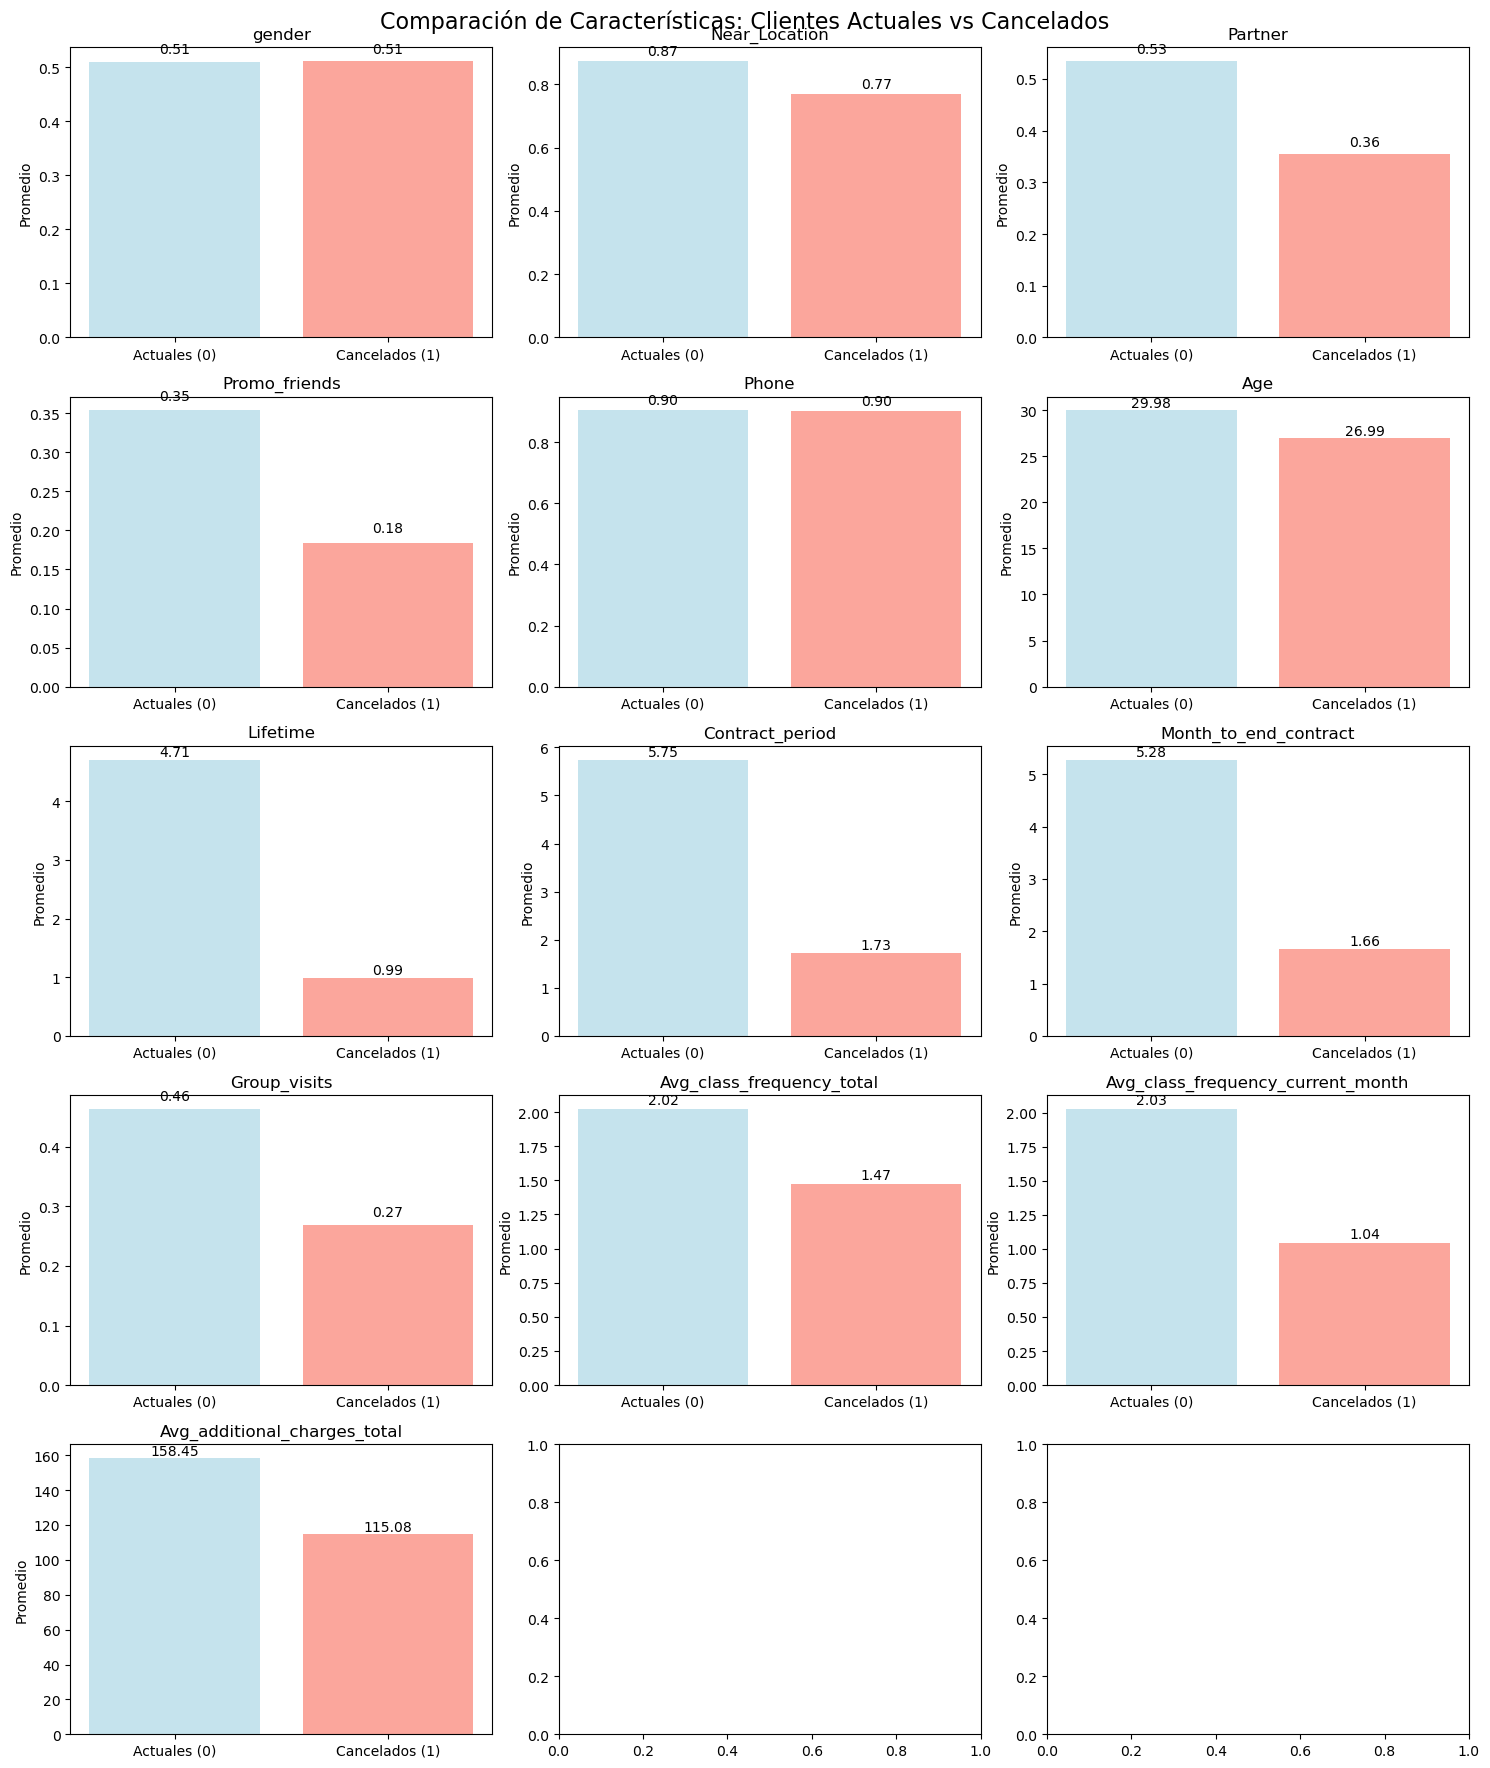

In [5]:

# Configurar el estilo de los gráficos
plt.style.use('default')
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
fig.suptitle('Comparación de Características: Clientes Actuales vs Cancelados', fontsize=16)

# Variables binarias/categóricas más importantes para visualizar

variables = [
'gender','Near_Location', 'Partner', 'Promo_friends', 'Phone','Age', 
             'Lifetime','Contract_period','Month_to_end_contract','Group_visits',
             'Avg_class_frequency_total','Avg_class_frequency_current_month',
             'Avg_additional_charges_total'
]


# Crear gráficos de barras para cada variable
for i, var in enumerate(variables):

    row = i // 3
    col = i % 3
    
    # Calcular medias por grupo de Churn

    means = cust_data.groupby('Churn')[var].mean()
    
    # Crear gráfico de barras
    bars = axes[row, col].bar(['Actuales (0)', 'Cancelados (1)'], means.values, 
                              color=['lightblue', 'salmon'], alpha=0.7)
    
    axes[row, col].set_title(f'{var}')
    axes[row, col].set_ylabel('Promedio')
    
    # Añadir valores en las barras
    for bar, value in zip(bars, means.values):
        axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


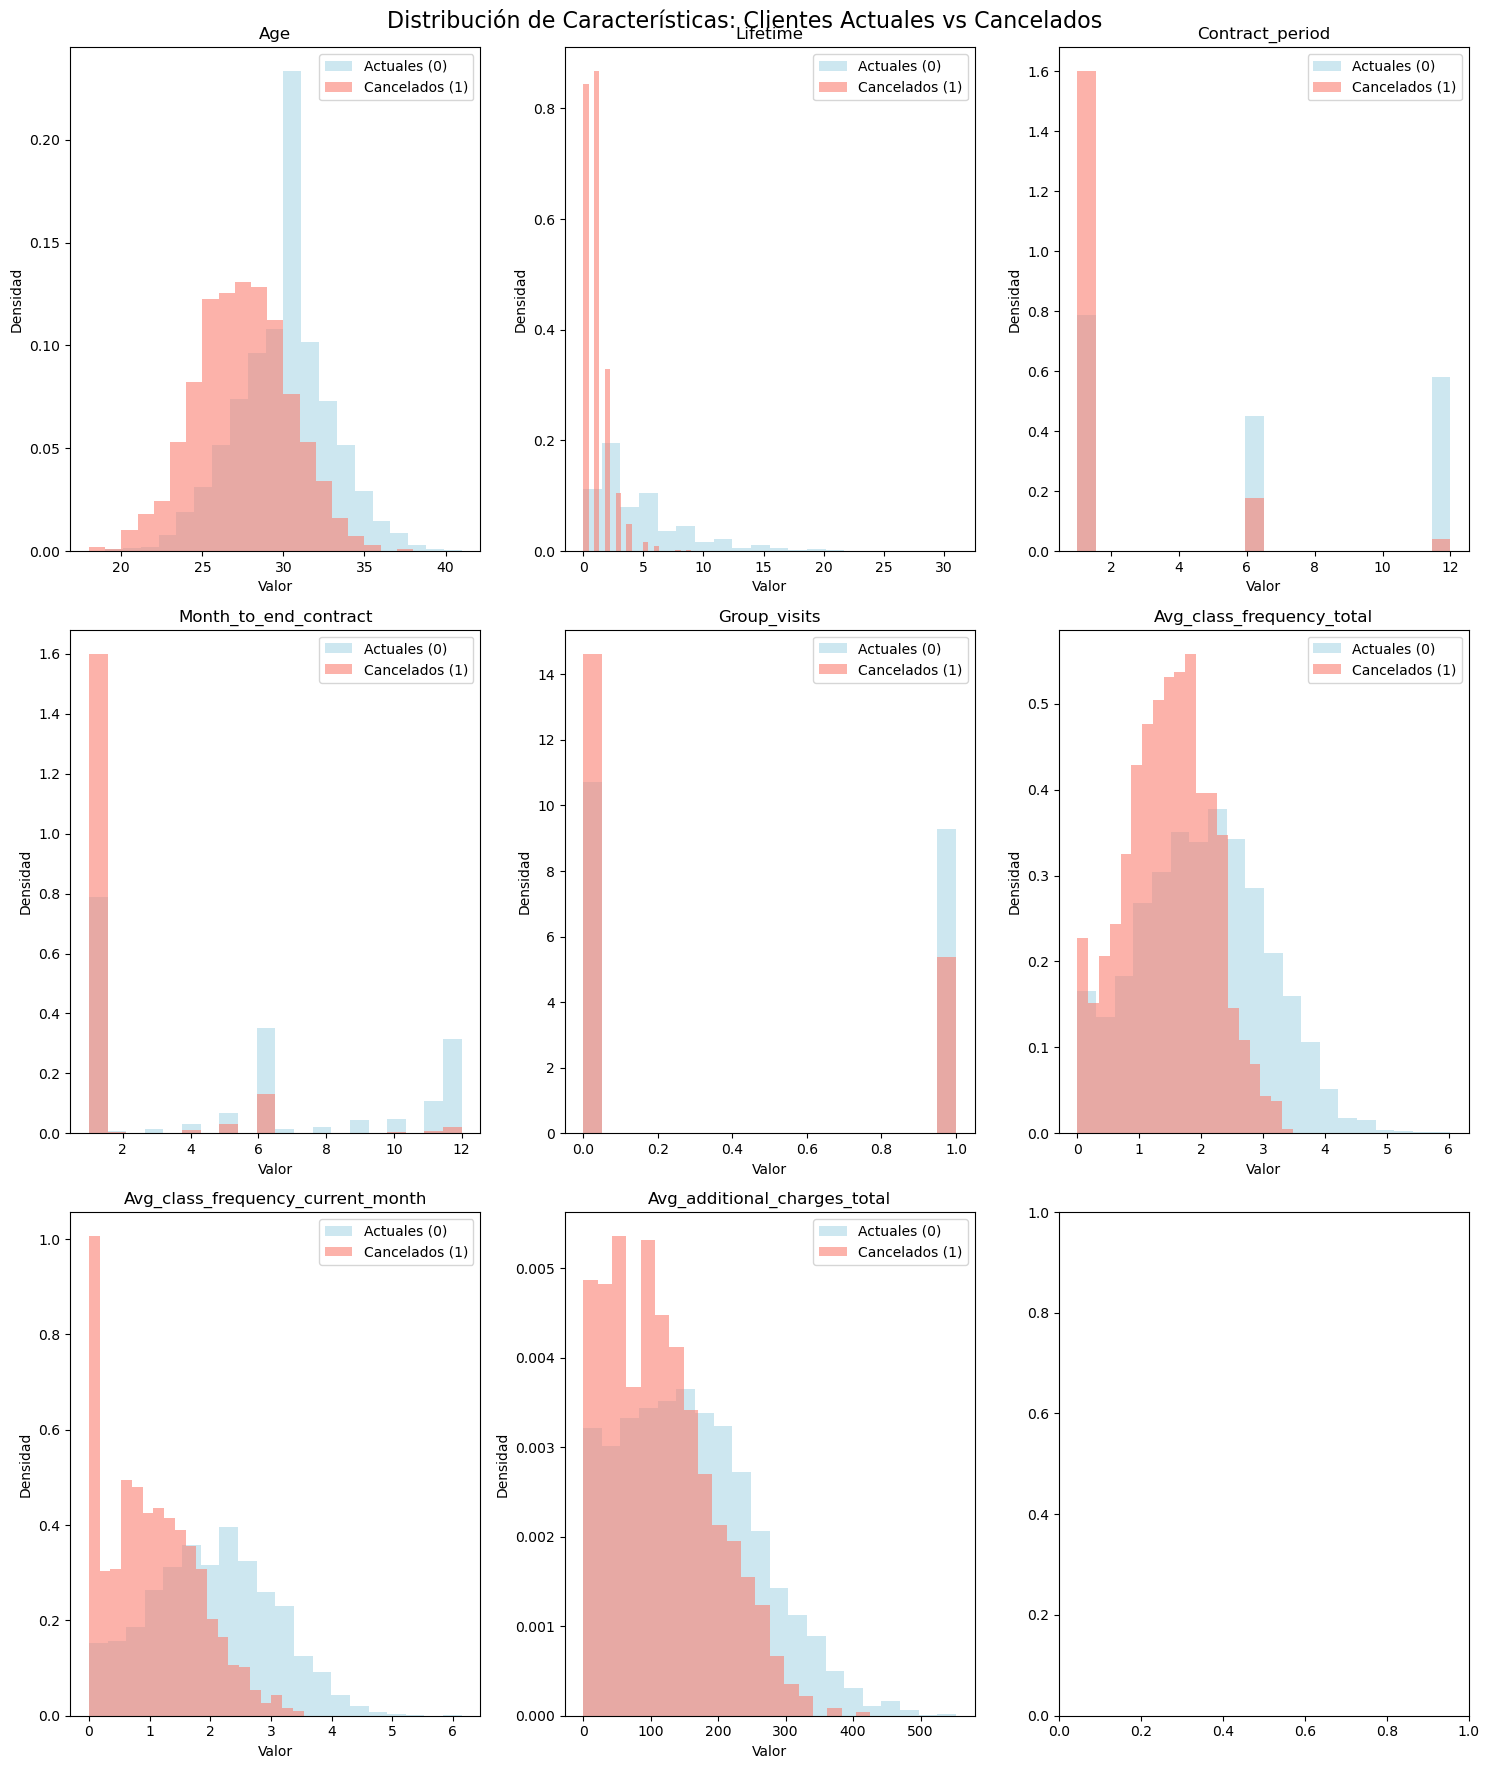

In [6]:

# Configurar el estilo de los gráficos
plt.style.use('default')
fig, axes = plt.subplots(3, 3, figsize=(15, 18))
fig.suptitle('Distribución de Características: Clientes Actuales vs Cancelados', fontsize=16)

# Variables para visualizar en histogramas
variables = ['Age','Lifetime','Contract_period','Month_to_end_contract',
             'Group_visits','Avg_class_frequency_total',
             'Avg_class_frequency_current_month','Avg_additional_charges_total']

# Crear histogramas para cada variable
for i, var in enumerate(variables):
    row = i // 3
    col = i % 3
    
    # Separar datos por grupo de Churn
    actuales = cust_data[cust_data['Churn'] == 0][var]
    cancelados = cust_data[cust_data['Churn'] == 1][var]
    
    # Crear histogramas superpuestos
    axes[row, col].hist(actuales, bins=20, alpha=0.6, label='Actuales (0)', 
                       color='lightblue', density=True)
    axes[row, col].hist(cancelados, bins=20, alpha=0.6, label='Cancelados (1)', 
                       color='salmon', density=True)
    
    axes[row, col].set_title(f'{var}')
    axes[row, col].set_xlabel('Valor')
    axes[row, col].set_ylabel('Densidad')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

Observaciones de los gráficos de barra y distribuciones:

***Diferencias más significativas entre clientes actuales vs cancelados:***

1. VARIABLES CON MAYOR IMPACTO (diferencias dramáticas):
- **Lifetime**: La diferencia más notable - clientes actuales (4.71) vs cancelados (0.99)
  → Los clientes nuevos tienen mayor riesgo de cancelación
- **Contract_period**: Clientes actuales (5.75) vs cancelados (1.73)
  → Contratos más largos = mayor retención
- **Avg_class_frequency_current_month**: Actuales (2.03) vs cancelados (1.04)
  → La actividad reciente es un fuerte predictor de retención

2. VARIABLES CON IMPACTO MODERADO:
- **Age**: Clientes más jóvenes (26.99) tienden a cancelar más que los mayores (29.98)
- **Near_Location**: Vivir cerca del gimnasio favorece la retención (0.87 vs 0.77)
- **Partner**: Trabajar en empresa asociada reduce cancelaciones (0.53 vs 0.36)
- **Avg_additional_charges_total**: Clientes que gastan más se quedan (158.45 vs 115.08)

3. VARIABLES CON POCO IMPACTO:
- **Gender**: Prácticamente sin diferencia (0.51 vs 0.51)
- **Phone**: Sin diferencia significativa (0.90 vs 0.90)

***Patrones de distribución observados en histogramas:***

1. Variables con distribuciones claramente diferentes:
- **Lifetime**: Clientes cancelados concentrados en valores bajos (0-2 meses)
- **Contract_period**: Cancelados predominan en contratos de 1 mes
- **Avg_class_frequency_current_month**: Cancelados muestran baja actividad reciente

2. Variables con distribuciones similares pero desplazadas:
- **Age**: Ambos grupos siguen distribución normal, pero cancelados ligeramente más jóvenes
- **Avg_additional_charges_total**: Forma similar, pero cancelados gastan menos

CONCLUSIÓN CLAVE:
Los factores más predictivos de cancelación son: tiempo de permanencia corto, 
contratos de corta duración, baja actividad reciente y menor compromiso económico.

## Matriz de correlación entre caracteríticas

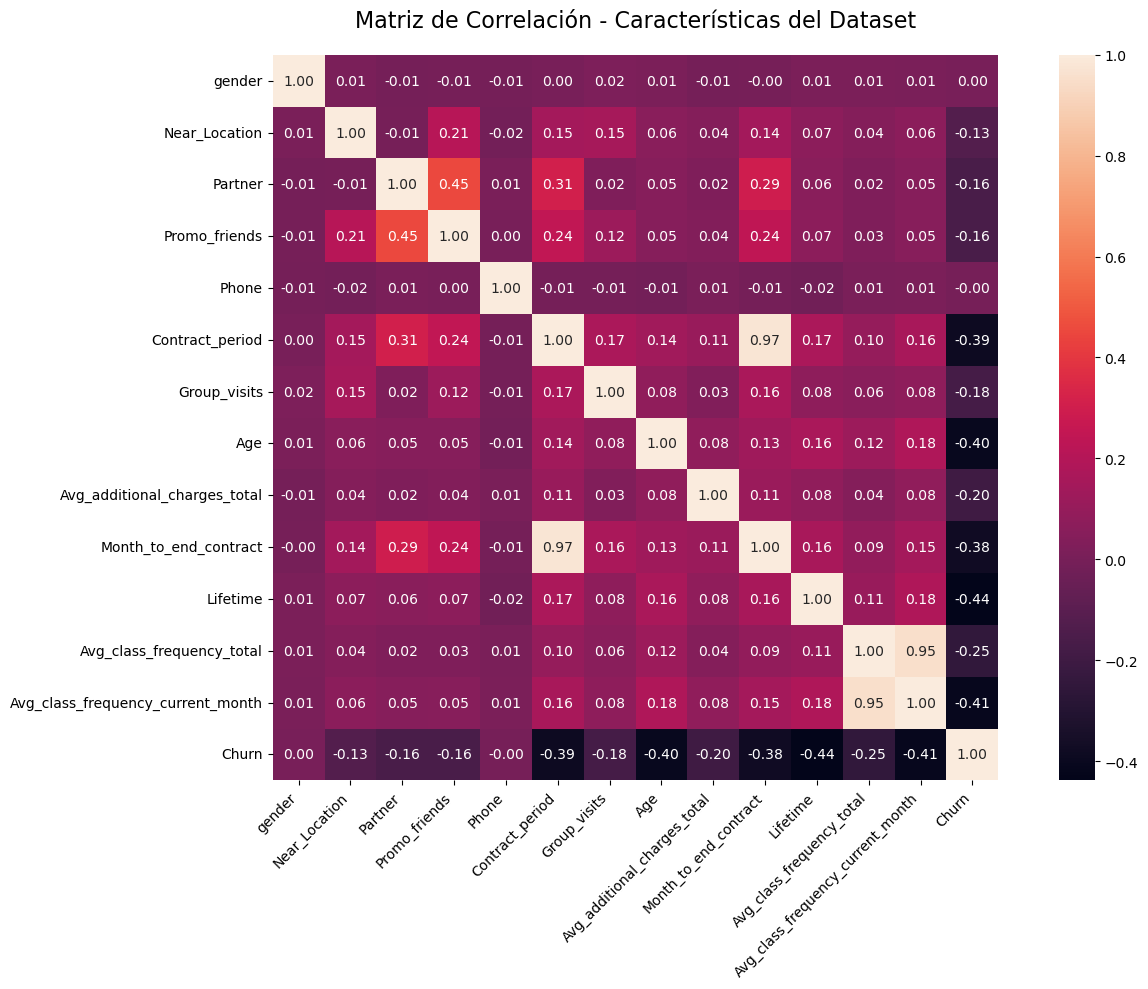

In [7]:
# Calcular la matriz de correlación
correlation_matrix = cust_data.corr()

# Configurar el tamaño de la figura
plt.figure(figsize=(14, 10))

# Crear el mapa de calor con seaborn
sns.heatmap(correlation_matrix, 
            annot=True,           # Mostrar valores numéricos
            square=True,          # Celdas cuadradas
            fmt='.2f')            # Formato de 2 decimales

plt.title('Matriz de Correlación - Características del Dataset', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x
plt.yticks(rotation=0)               # Mantener etiquetas del eje y horizontales
plt.tight_layout()
plt.show()

Conclusiones de la matriz de correlación

1. CORRELACIONES MÁS FUERTES CON CHURN (Variable objetivo):

***Correlaciones ordenadas de forma descendente acorde a su magnitud:***
- Lifetime (**negativo**) = -0.44
- Avg_class_frequency_current_month (**negativo**) = -0.41
- Age (**negativo**) = -0.40
- Contract_period (**negativo**) = -0.39
- Month_to_end_contract (**negativo**) = -0.38
- Avg_class_frequency_total (**negativo**) = -0.25
- Avg_additional_charges_total (**negativo**) = -0.20
- Group_visits (**negativo**) = -0.18
- Partner (**negativo**) = -0.16
- Promo_friends (**negativo**) = -0.16
- Near_Location (**negativo**) = -0.13
- Phone (**neutra**) = 0
- Gender (**neutra**) = 0

2. MULTICOLINEALIDAD DETECTADA (correlaciones altas entre variables independientes):

- **Contract_period vs Month_to_end_contract**: 0.97 
    Estas variables son prácticamente la misma información
- **Avg_class_frequency_total vs Avg_class_frequency_current_month**: 0.95
    Fuerte relación entre las frecuencias media de visitas en el mes en curso y en la vida del cliente

3. RECOMENDACIONES PARA MODELADO:

Variables a considerar eliminar por multicolinealidad:
- Considerar mantener solo **Month_to_end_contract** o **Contract_period** (no ambas)
- Considerar mantener solo **Avg_class_frequency_total** o **Avg_class_frequency_current_month** (no ambas)

Variables más valiosas para predicción:
- Lifetime
- Avg_class_frequency_current_month
- Age
- Contract_period
- Month_to_end_contract

4. INSIGHT CLAVE:
La multicolinealidad entre variables temporales (Lifetime, Contract_period, Month_to_end_contract) 
sugiere que el TIEMPO es el factor fundamental en la retención de clientes.

## Eliminación de las características innecesarias

### Evaluación y eliminación de valores anómalos

Los percentiles 90, 95 y 99 de la variable 'Lifetime' son: [ 9. 11. 17.]
Los percentiles 90, 95 y 99 de la variable 'Avg_additional_charges_total' son: [277.7171989  323.44087589 400.99612505]
Los percentiles 90, 95 y 99 de la variable 'Contract_period' son: [12. 12. 12.]


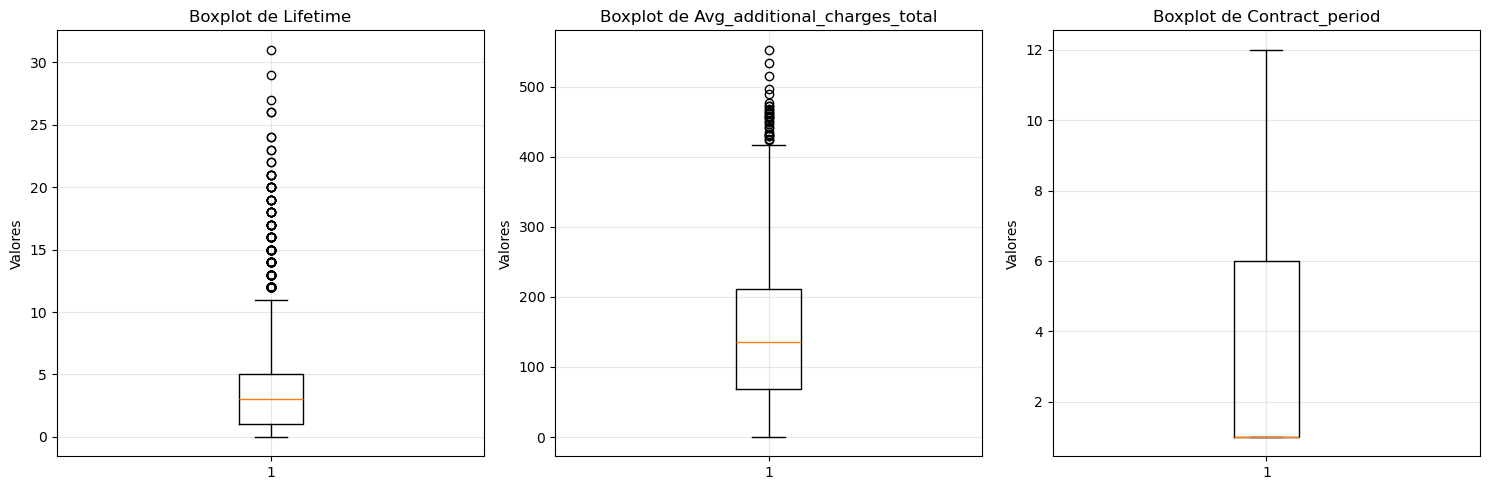

In [8]:
# Verificación de percentiles para los datos en Lifetime
print("Los percentiles 90, 95 y 99 de la variable 'Lifetime' son:", np.percentile(cust_data['Lifetime'], [90, 95, 99]))
# Verificación de percentiles para los datos en Avg_additional_charges_total
print("Los percentiles 90, 95 y 99 de la variable 'Avg_additional_charges_total' son:", np.percentile(cust_data['Avg_additional_charges_total'], [90, 95, 99]))
# Verificación de percentiles para los datos en Contract_period
print("Los percentiles 90, 95 y 99 de la variable 'Contract_period' son:", np.percentile(cust_data['Contract_period'], [90, 95, 99]))
# Generación de boxplots para estas mismas variables
# Configurar el tamaño de la figura
plt.figure(figsize=(15, 5))

# Lista de variables a analizar
variables = ['Lifetime', 'Avg_additional_charges_total', 'Contract_period']

# Crear subplots
for i, variable in enumerate(variables, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(cust_data[variable])
    plt.title(f'Boxplot de {variable}')
    plt.ylabel('Valores')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Acorde a los percentiles observados, se toman las siguientes decisiones:
- Para la característica **Lifetime**, se eliminarán todos los datos de clientes con lifetimes mayores a 11 (percentil 95)
- Para la característica **Avg_additional_charges_total**, se eliminarán todos los datos de clientes con lifetimes mayores a 400.99 (percentil 99)
- Para la característica **Contract_period**, no se eliminaran datos, debido a que para los clientes vigentes, existen considerables datos todavía hasta el percentil 99.

In [9]:
cust_data_clean=cust_data[(cust_data['Lifetime']<=11) & (cust_data['Avg_additional_charges_total']<=400.99612505)]
print(cust_data_clean.info())
print(cust_data_clean.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 3770 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             3770 non-null   int64  
 1   Near_Location                      3770 non-null   int64  
 2   Partner                            3770 non-null   int64  
 3   Promo_friends                      3770 non-null   int64  
 4   Phone                              3770 non-null   int64  
 5   Contract_period                    3770 non-null   int64  
 6   Group_visits                       3770 non-null   int64  
 7   Age                                3770 non-null   int64  
 8   Avg_additional_charges_total       3770 non-null   float64
 9   Month_to_end_contract              3770 non-null   float64
 10  Lifetime                           3770 non-null   int64  
 11  Avg_class_frequency_total          3770 non-null   float64
 1

### Evaluación y eliminación de multilinealidades

In [10]:
# Analiza la relación entre Contract_period y Month_to_end_contract
print("CORRELACIÓN ENTRE Contract_period y Month_to_end_contract:")
print(cust_data[['Contract_period', 'Month_to_end_contract']].corr())

# Analiza cuál predice mejor el Churn
print("\nRELACIÓN CON Churn:")
print("Por Contract_period:")
print(cust_data.groupby('Contract_period')['Churn'].mean())
print("\nPor Month_to_end_contract:")
print(cust_data.groupby('Month_to_end_contract')['Churn'].mean())

# Analiza la relación entre Avg_class_frequency_total y Avg_class_frequency_current_month
print("\nCORRELACIÓN ENTRE Avg_class_frequency_total y Avg_class_frequency_current_month:")
print(cust_data[['Avg_class_frequency_total', 'Avg_class_frequency_current_month']].corr())

# Analiza cuál predice mejor el Churn
print("\nRELACIÓN CON Churn:")
print("Por Avg_class_frequency_total:")
print(cust_data.groupby('Avg_class_frequency_total')['Churn'].mean())
print("\nPor Avg_class_frequency_current_month:")
print(cust_data.groupby('Avg_class_frequency_current_month')['Churn'].mean())


CORRELACIÓN ENTRE Contract_period y Month_to_end_contract:
                       Contract_period  Month_to_end_contract
Contract_period               1.000000               0.973064
Month_to_end_contract         0.973064               1.000000

RELACIÓN CON Churn:
Por Contract_period:
Contract_period
1     0.423199
6     0.124850
12    0.023958
Name: Churn, dtype: float64

Por Month_to_end_contract:
Month_to_end_contract
1.0     0.423199
2.0     0.142857
3.0     0.043478
4.0     0.120690
5.0     0.146154
6.0     0.117829
7.0     0.040000
8.0     0.026316
9.0     0.013699
10.0    0.024390
11.0    0.022099
12.0    0.024809
Name: Churn, dtype: float64

CORRELACIÓN ENTRE Avg_class_frequency_total y Avg_class_frequency_current_month:
                                   Avg_class_frequency_total  \
Avg_class_frequency_total                           1.000000   
Avg_class_frequency_current_month                   0.952739   

                                   Avg_class_frequency_current_mont

**Variables Eliminadas y Razones:**
1. Contract_period (Eliminada)

Se decidió eliminar esta variable debido a su alta correlación (0.97) con Month_to_end_contract. Aunque ambas variables muestran una relación fuerte con el churn, se optó por conservar Month_to_end_contract porque:
- Proporciona información más granular sobre el tiempo restante del contrato
- Ofrece mayor variabilidad en los datos (valores de 1 a 12 meses vs. solo 1, 6 y 12 meses)
- Permite una mejor comprensión del comportamiento del cliente en diferentes etapas del contrato

2. Avg_class_frequency_total (Eliminada)

Esta variable fue eliminada por su alta correlación (0.95) con Avg_class_frequency_current_month. La decisión de conservar la frecuencia del mes actual se basa en:
- Mayor poder predictivo: La actividad reciente es un mejor indicador del comportamiento futuro del cliente
- Relevancia temporal: El comportamiento del mes actual refleja mejor la situación presente del cliente que el promedio histórico
- Capacidad de detección temprana: Permite identificar cambios recientes en los patrones de uso que podrían indicar riesgo de cancelación

**Variables Conservadas y su Valor:**
1. Month_to_end_contract: Mantiene la información contractual esencial sin redundancia, proporcionando insight sobre el compromiso temporal del cliente.

2. Avg_class_frequency_current_month: Ofrece la métrica más actualizada y relevante sobre el nivel de engagement del cliente con los servicios del gimnasio.

Esta decisión optimiza el modelo eliminando redundancia mientras preserva la información más predictiva y actionable para la estrategia de retención de clientes.

In [11]:
cust_data_clean=cust_data_clean.drop(['Contract_period','Avg_class_frequency_total'],axis=1)
print(cust_data_clean.info())
print(cust_data_clean.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 3770 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             3770 non-null   int64  
 1   Near_Location                      3770 non-null   int64  
 2   Partner                            3770 non-null   int64  
 3   Promo_friends                      3770 non-null   int64  
 4   Phone                              3770 non-null   int64  
 5   Group_visits                       3770 non-null   int64  
 6   Age                                3770 non-null   int64  
 7   Avg_additional_charges_total       3770 non-null   float64
 8   Month_to_end_contract              3770 non-null   float64
 9   Lifetime                           3770 non-null   int64  
 10  Avg_class_frequency_current_month  3770 non-null   float64
 11  Churn                              3770 non-null   int64  
dt

# Paso 3. Construir un modelo para predecir la cancelación de usuarios

## División de los datos en conjuntos de entrenamiento y validación

In [12]:
# Separación de matriz de valores de características y vector de valores objetivo
X = cust_data_clean.drop(['Churn'],axis=1)
y = cust_data_clean['Churn']
# Segmentación de datos por datos de entrenamiento y de validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Estandarización y entrenamiento del modelo con el set de entrenamiento

In [13]:
# Normalización de datos
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

# Entrenamiento de datos
model_1 = LogisticRegression(random_state=0)
model_2 = RandomForestClassifier(random_state=0)
model_1.fit(X_train_st, y_train)
model_2.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluación de la exactitud, precisión y recall para ambos modelos

In [14]:
def make_prediction(model, X_test, y_test):
    '''
    
Esta función genera predicciones con base en el entrenamiento que
    previamente ya se debió haber generado y regresa el valor de las 
    métricas evaluadas (considera que serán métricas para regresión 
    logística y bosque aleatorio).
    
    Parameters
    ----------
    X_test : pandas.DataFrame
        Características de validación (features)
    y_test : pandas.Series
        Variable objetivo (target) con valores de churn
    model : str
        Tipo de modelo a entrenar ('logistic' o 'random_forest')
        Debes capturar cualquiera de los siguientes dos valores acorde
        al tipo de modelo con el que quieres predecir:
        - logistic = model_1
        - random_forest = model_2
    
    Returns
    -------
    Impresión de los valores de las métricas generadas por el modelo

    '''

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score (y_test, y_pred)
    recall = recall_score (y_test, y_pred)
    return print(f"Exactitud = {acc:.2f}\nPrecisión = {precision:.2f}\nRecall = {recall:.2f}")

#Evaluación de métricas para cada algoritmo
print("Métricas para modelo regresión logística")
make_prediction(model_1, X_test_st, y_test)
print("Métricas para modelo bosque aleatoria")
make_prediction(model_2, X_test, y_test)

Métricas para modelo regresión logística
Exactitud = 0.91
Precisión = 0.82
Recall = 0.82
Métricas para modelo bosque aleatoria
Exactitud = 0.90
Precisión = 0.82
Recall = 0.78


Para el objetivo específico de combatir la cancelación, la métrica más importante es el Recall (también llamado Sensibilidad), debido a que:

Recall mide: ¿De todos los clientes que SÍ van a cancelar, cuántos logra identificar correctamente el modelo?

En el contexto: Es más costoso NO detectar a un cliente que se va a ir (falso negativo) que invertir recursos en retener a alguien que no se iba a cancelar (falso positivo)

¿Cuál métrica es mejor?

Regresión Logística: Recall = 0.82 (82%)

Random Forest: Recall = 0.78 (78%)

Por ende, se toma como decisión que el mejor algoritmo para este caso será Regresión logística.

# Paso 4. Crear clústeres de usuarios/as

## Dendrograma de características estandarizada

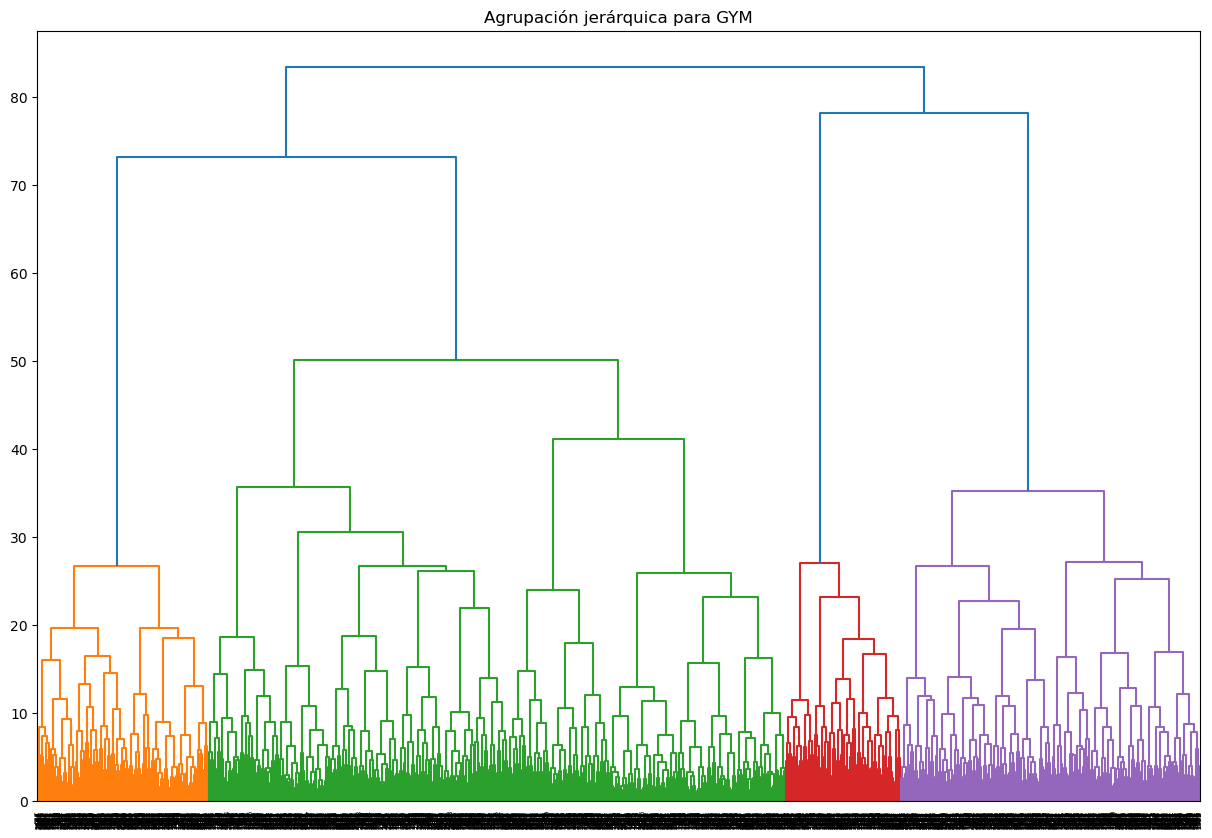

In [15]:
# Generación de dendrograma
linked = linkage(X_train_st, method = 'ward')
# Impresión de dendrograma
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para GYM')
plt.show()

Alternativas a considerar:
- 3 clústeres: Si cortas más arriba (~70-75), más simple pero menos detallado
- 4 clústeres: Corte intermedio, buen balance
- 6-7 clústeres: Más detallado pero puede ser demasiado fragmentado

Se comenzará con una propuesta inicial de 5 clústeres y se optará por cambiar ese número acorde a como ser perciba el resultado respecto a si los perfiles de clientes resultantes son:

- Distintos entre sí
- Interpretables para el negocio
- Útiles para estrategias de retención

## Entrenamiento del modelo de clustering con el algortimo K-means y predicción de los clústeres de clientes.

In [16]:
# Definición de modelo de clustering, entrenamiento y predicción
model_3 = KMeans(n_clusters = 5)
labels = model_3.fit_predict(X_test_st)

# Crear DataFrame con los datos de test y las etiquetas de clúster
X_test_with_clusters = X_test.copy()
X_test_with_clusters['Cluster'] = labels

# Calcular valores medios por clúster
cluster_means = X_test_with_clusters.groupby('Cluster').mean()
print("Valores medios por clúster:")
print(cluster_means)

Valores medios por clúster:
           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.576159       0.980132  0.854305       0.582781  0.880795   
1        0.537736       0.000000  0.518868       0.047170  0.905660   
2        0.510791       1.000000  0.136691       0.079137  0.906475   
3        0.401408       1.000000  0.852113       1.000000  0.957746   
4        0.504630       1.000000  0.282407       0.000000  0.921296   

         Group_visits        Age  Avg_additional_charges_total  \
Cluster                                                          
0            0.821192  30.688742                    182.004587   
1            0.198113  28.490566                    128.142737   
2            1.000000  28.762590                    129.948552   
3            0.218310  28.929577                    122.632429   
4            0.000000  28.861111                    139.513222   

         Mo

C:\Users\andre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


***Descubrimientos generados***
1. Clúster 4 - El grupo "sin teléfono":

Phone = 0.0 (¡Es el único clúster donde NADIE proporcionó teléfono!)
Este es un patrón muy distintivo y preocupante para el negocio

2. Clúster 0 - El grupo "promocional perfecto":

Promo_friends = 1.0 (¡TODOS vinieron por promoción de amigos!)
Near_Location = 0.995 (casi todos viven cerca)
Partner = 0.894 (mayoría trabaja en empresas asociadas)

3. Clúster 2 - El grupo "lejano":

Near_Location = 0.0 (¡NADIE vive cerca del gimnasio!)
Menor engagement general

## Distribuciones de características para los clústeres.

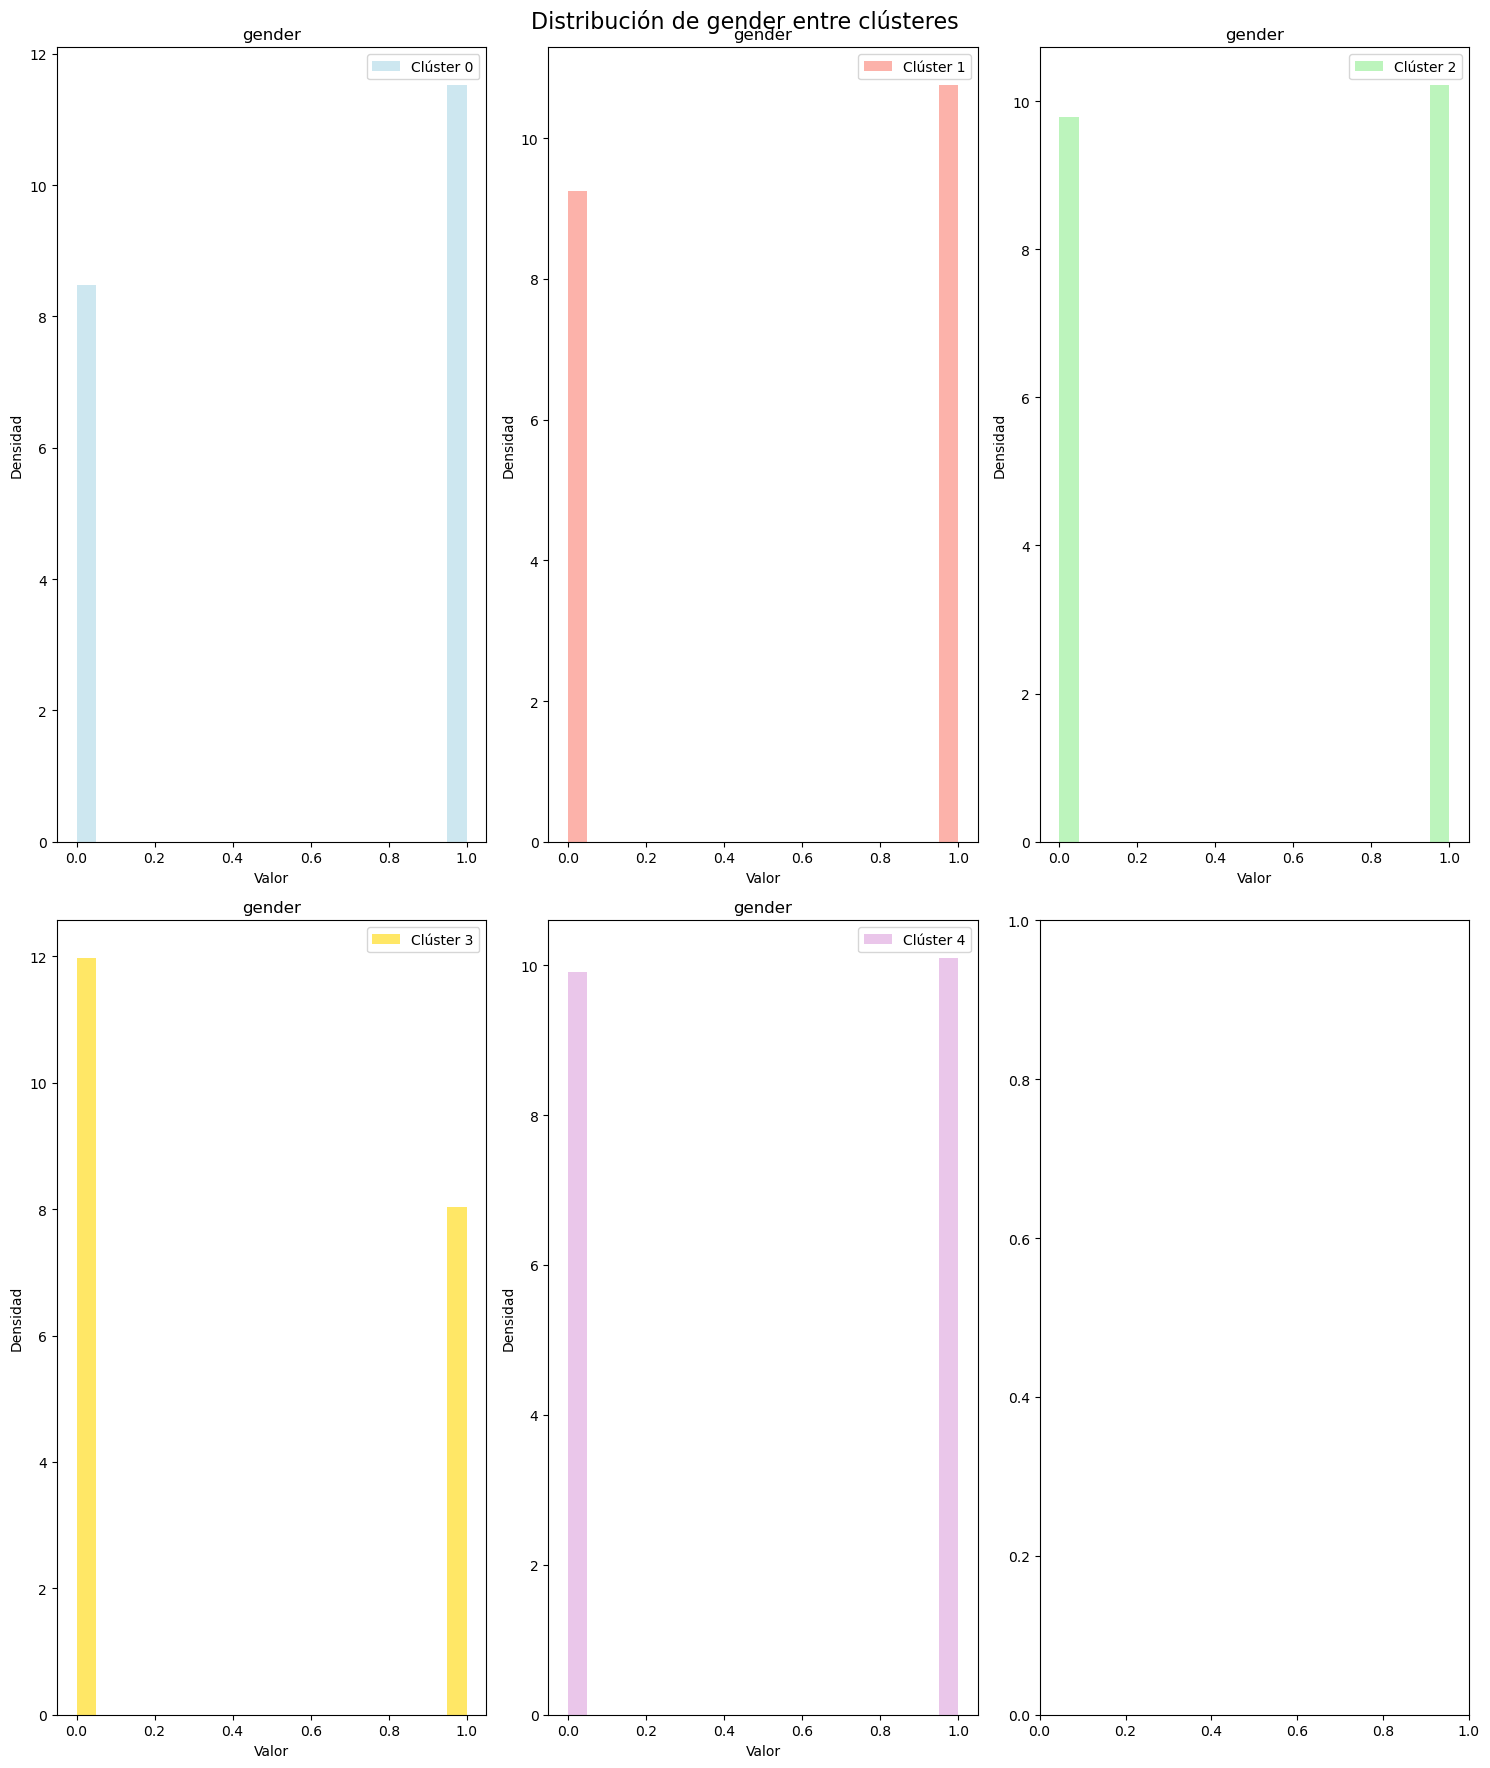

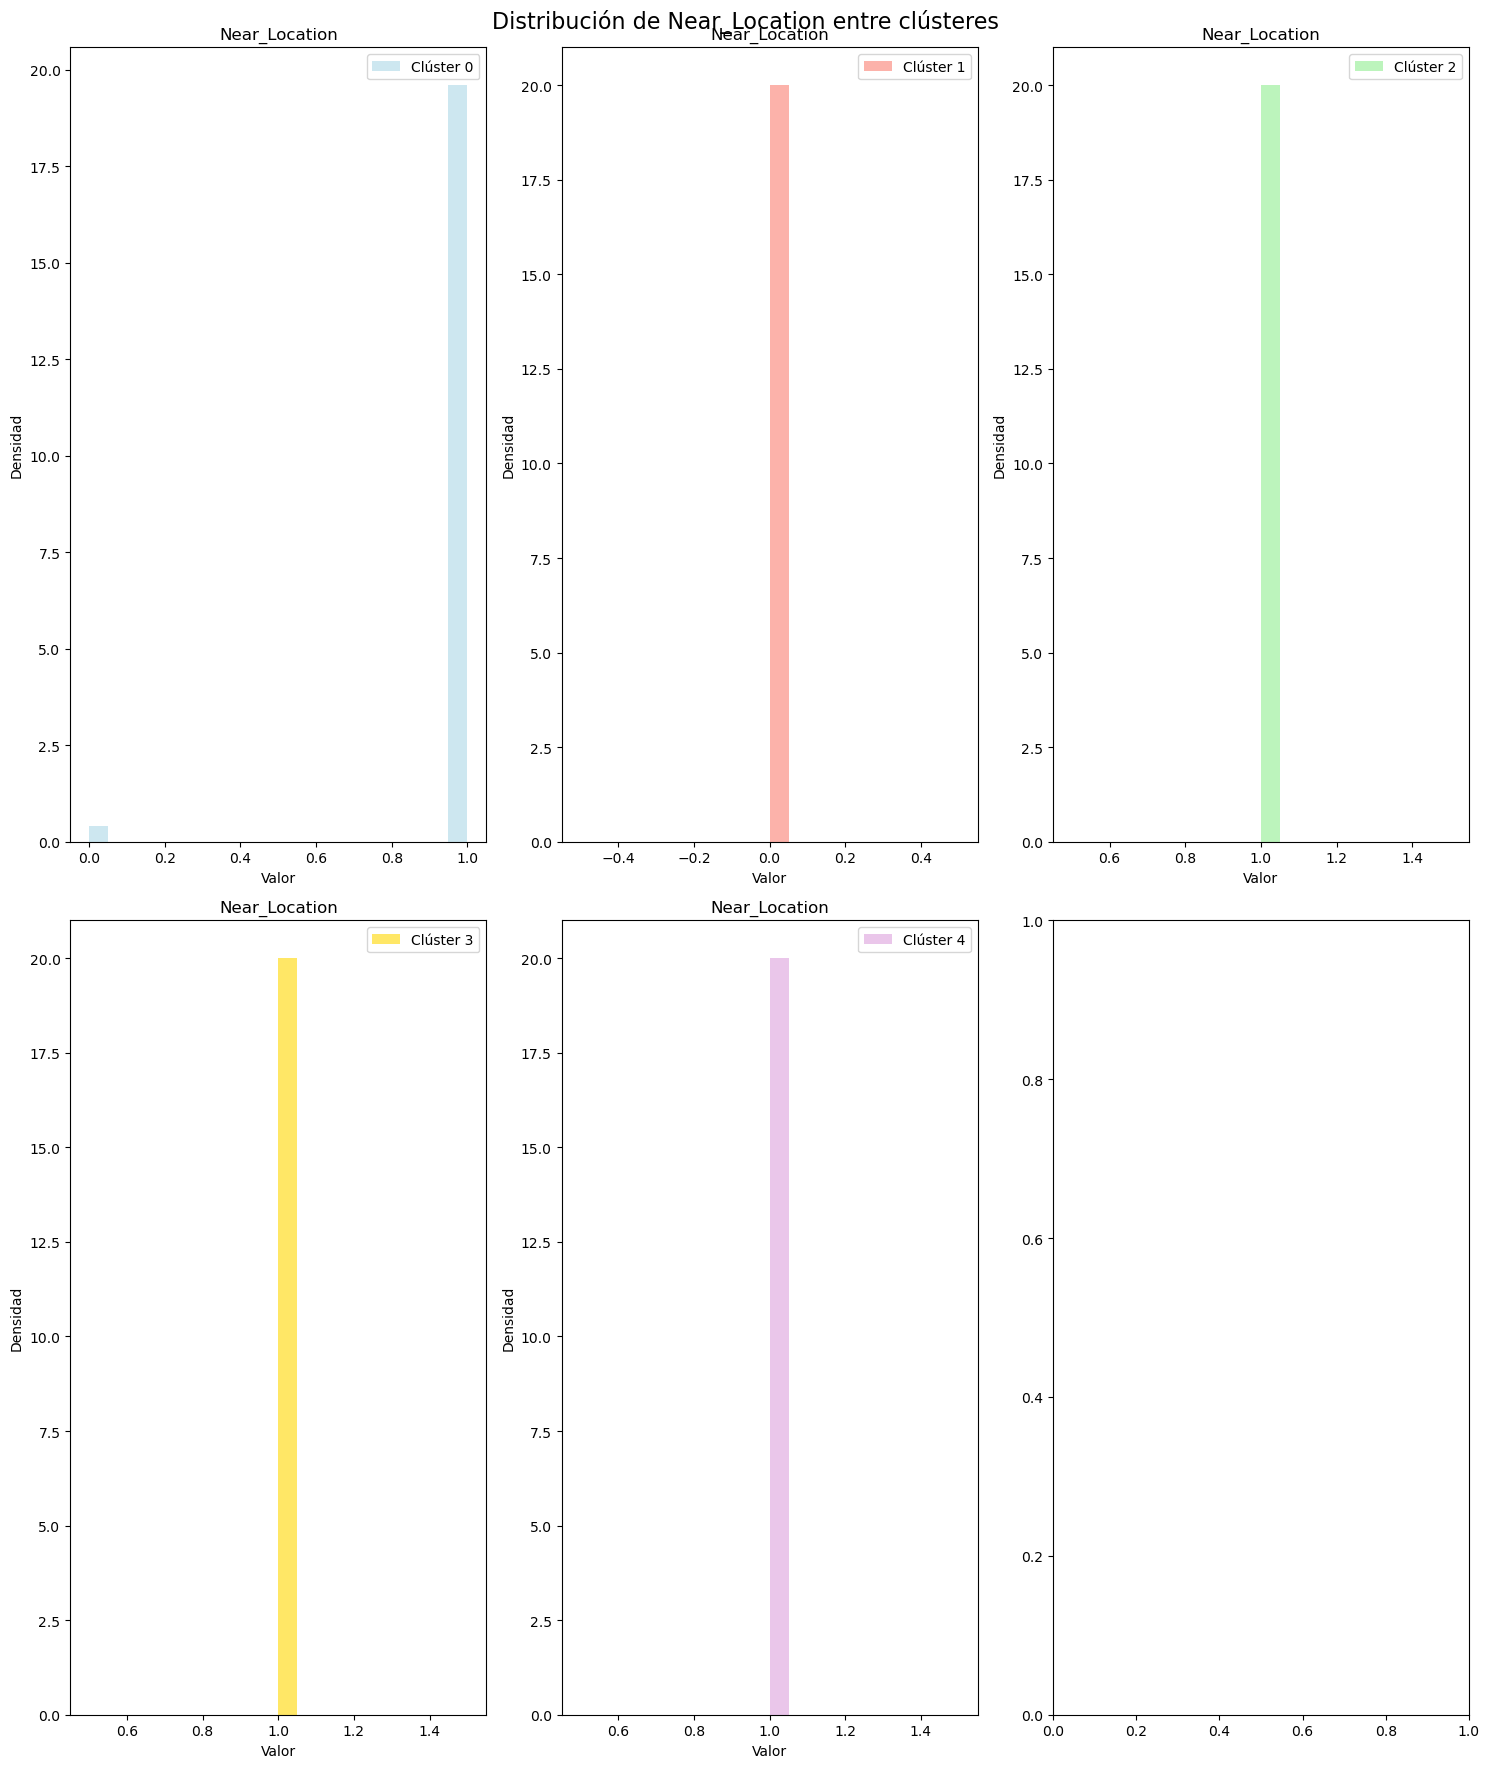

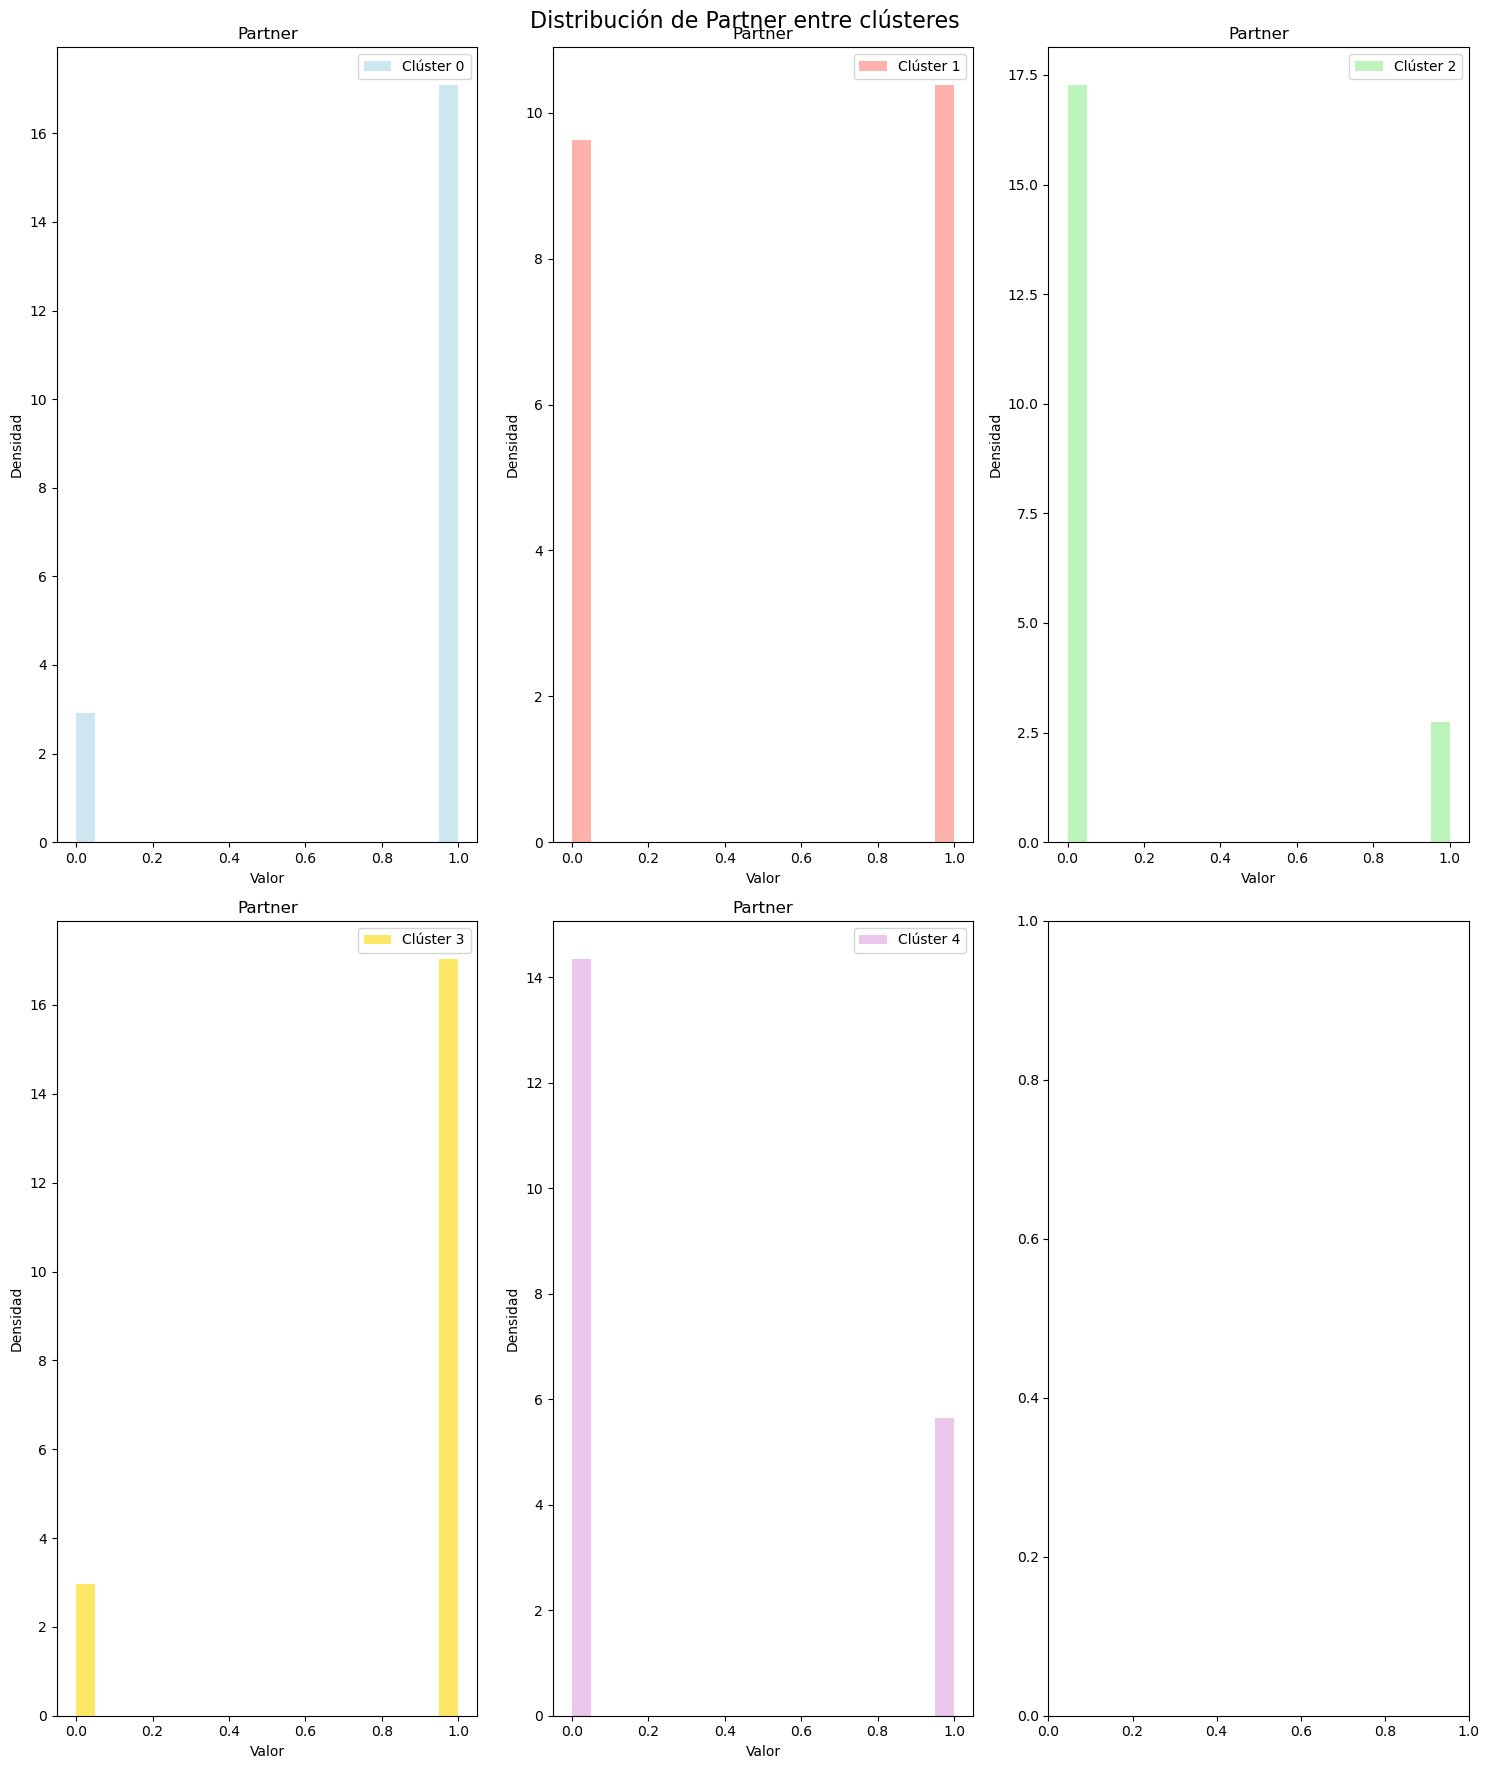

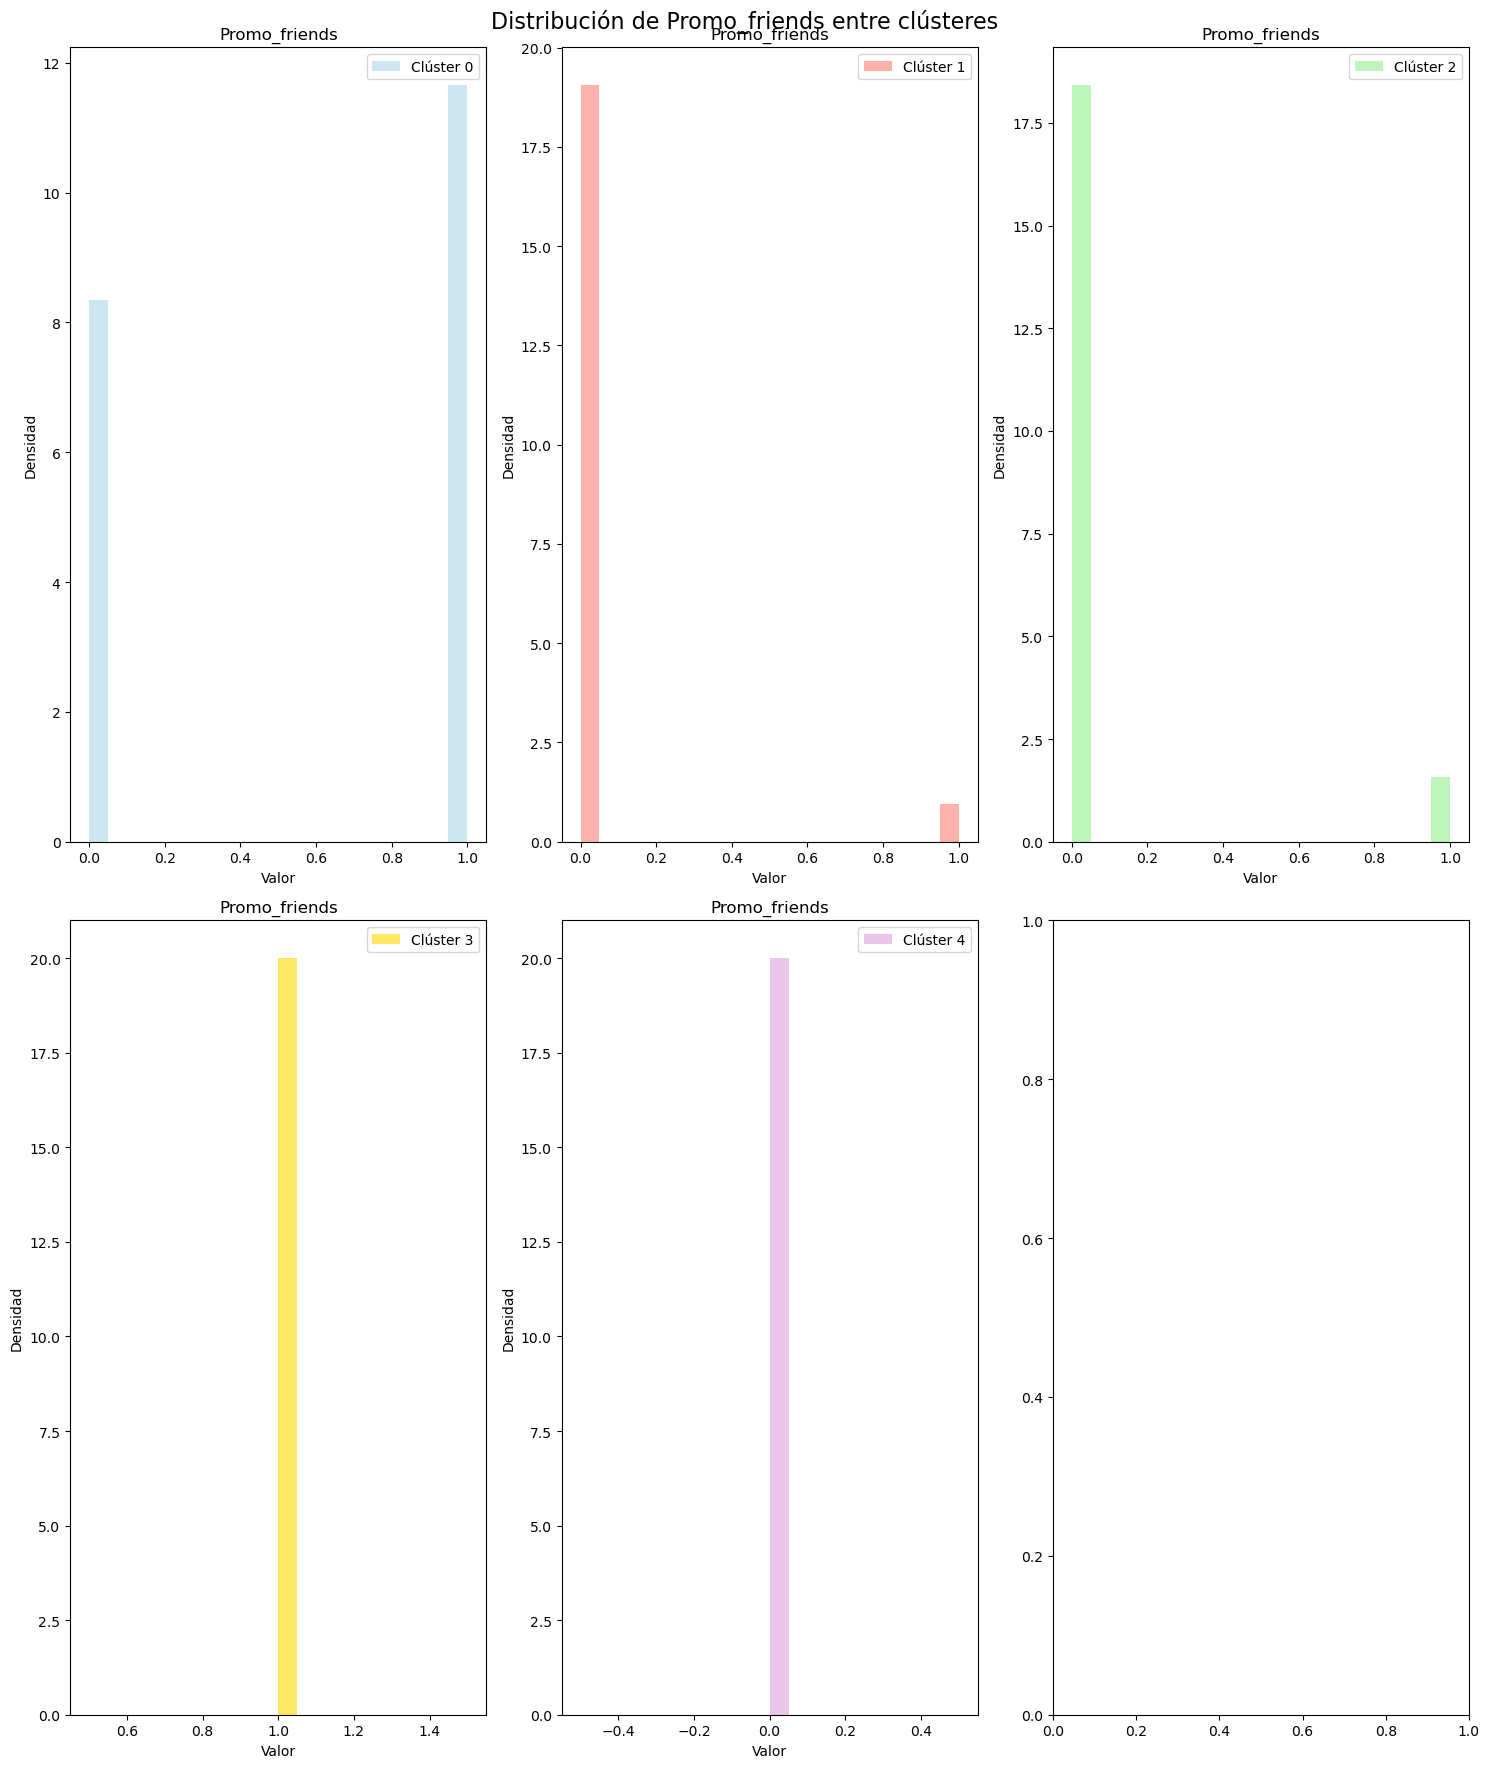

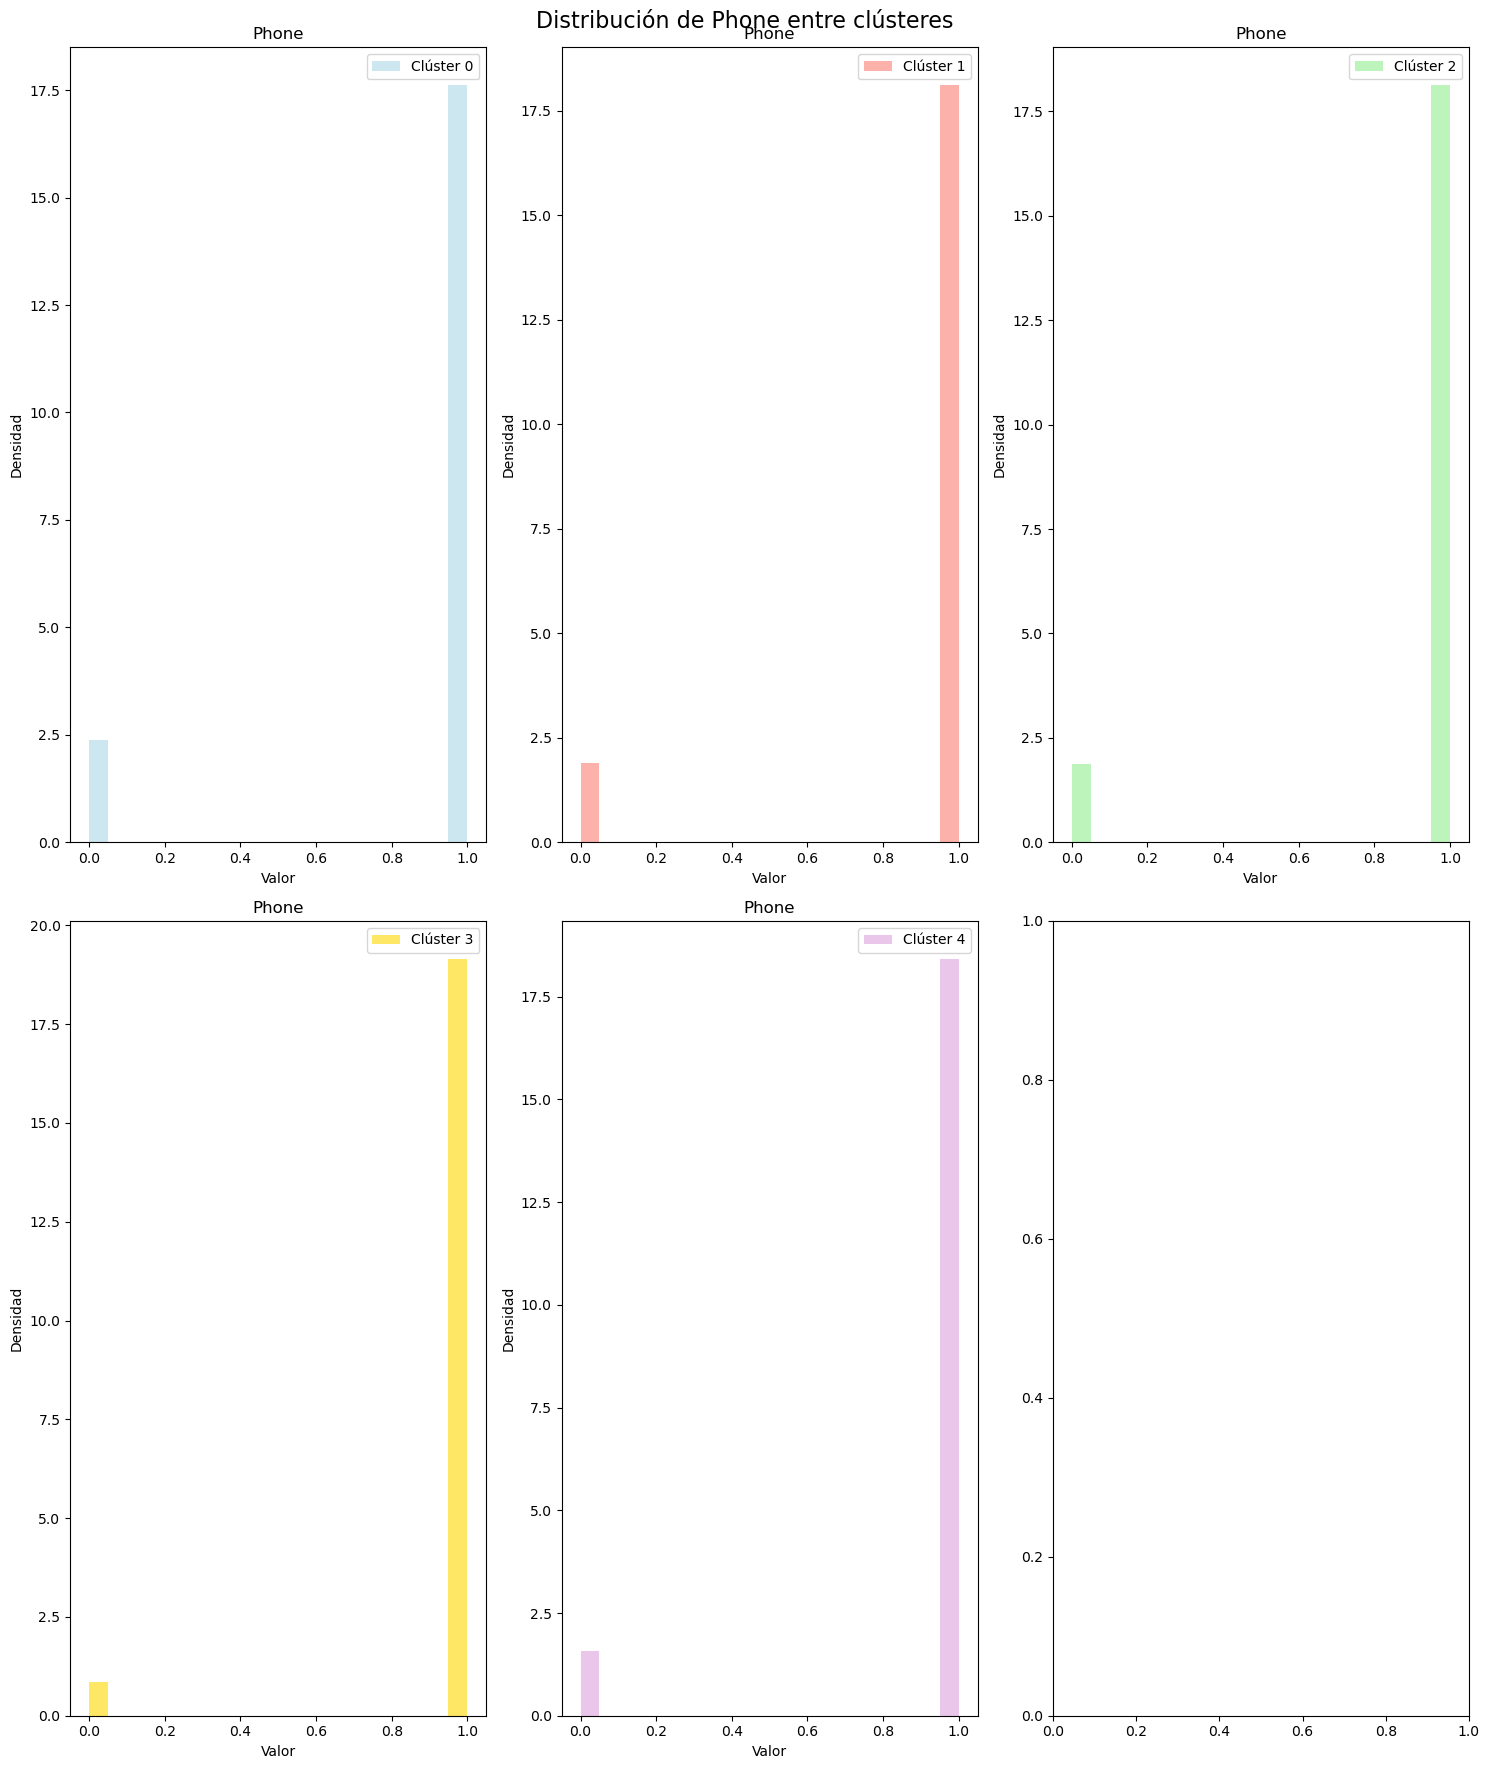

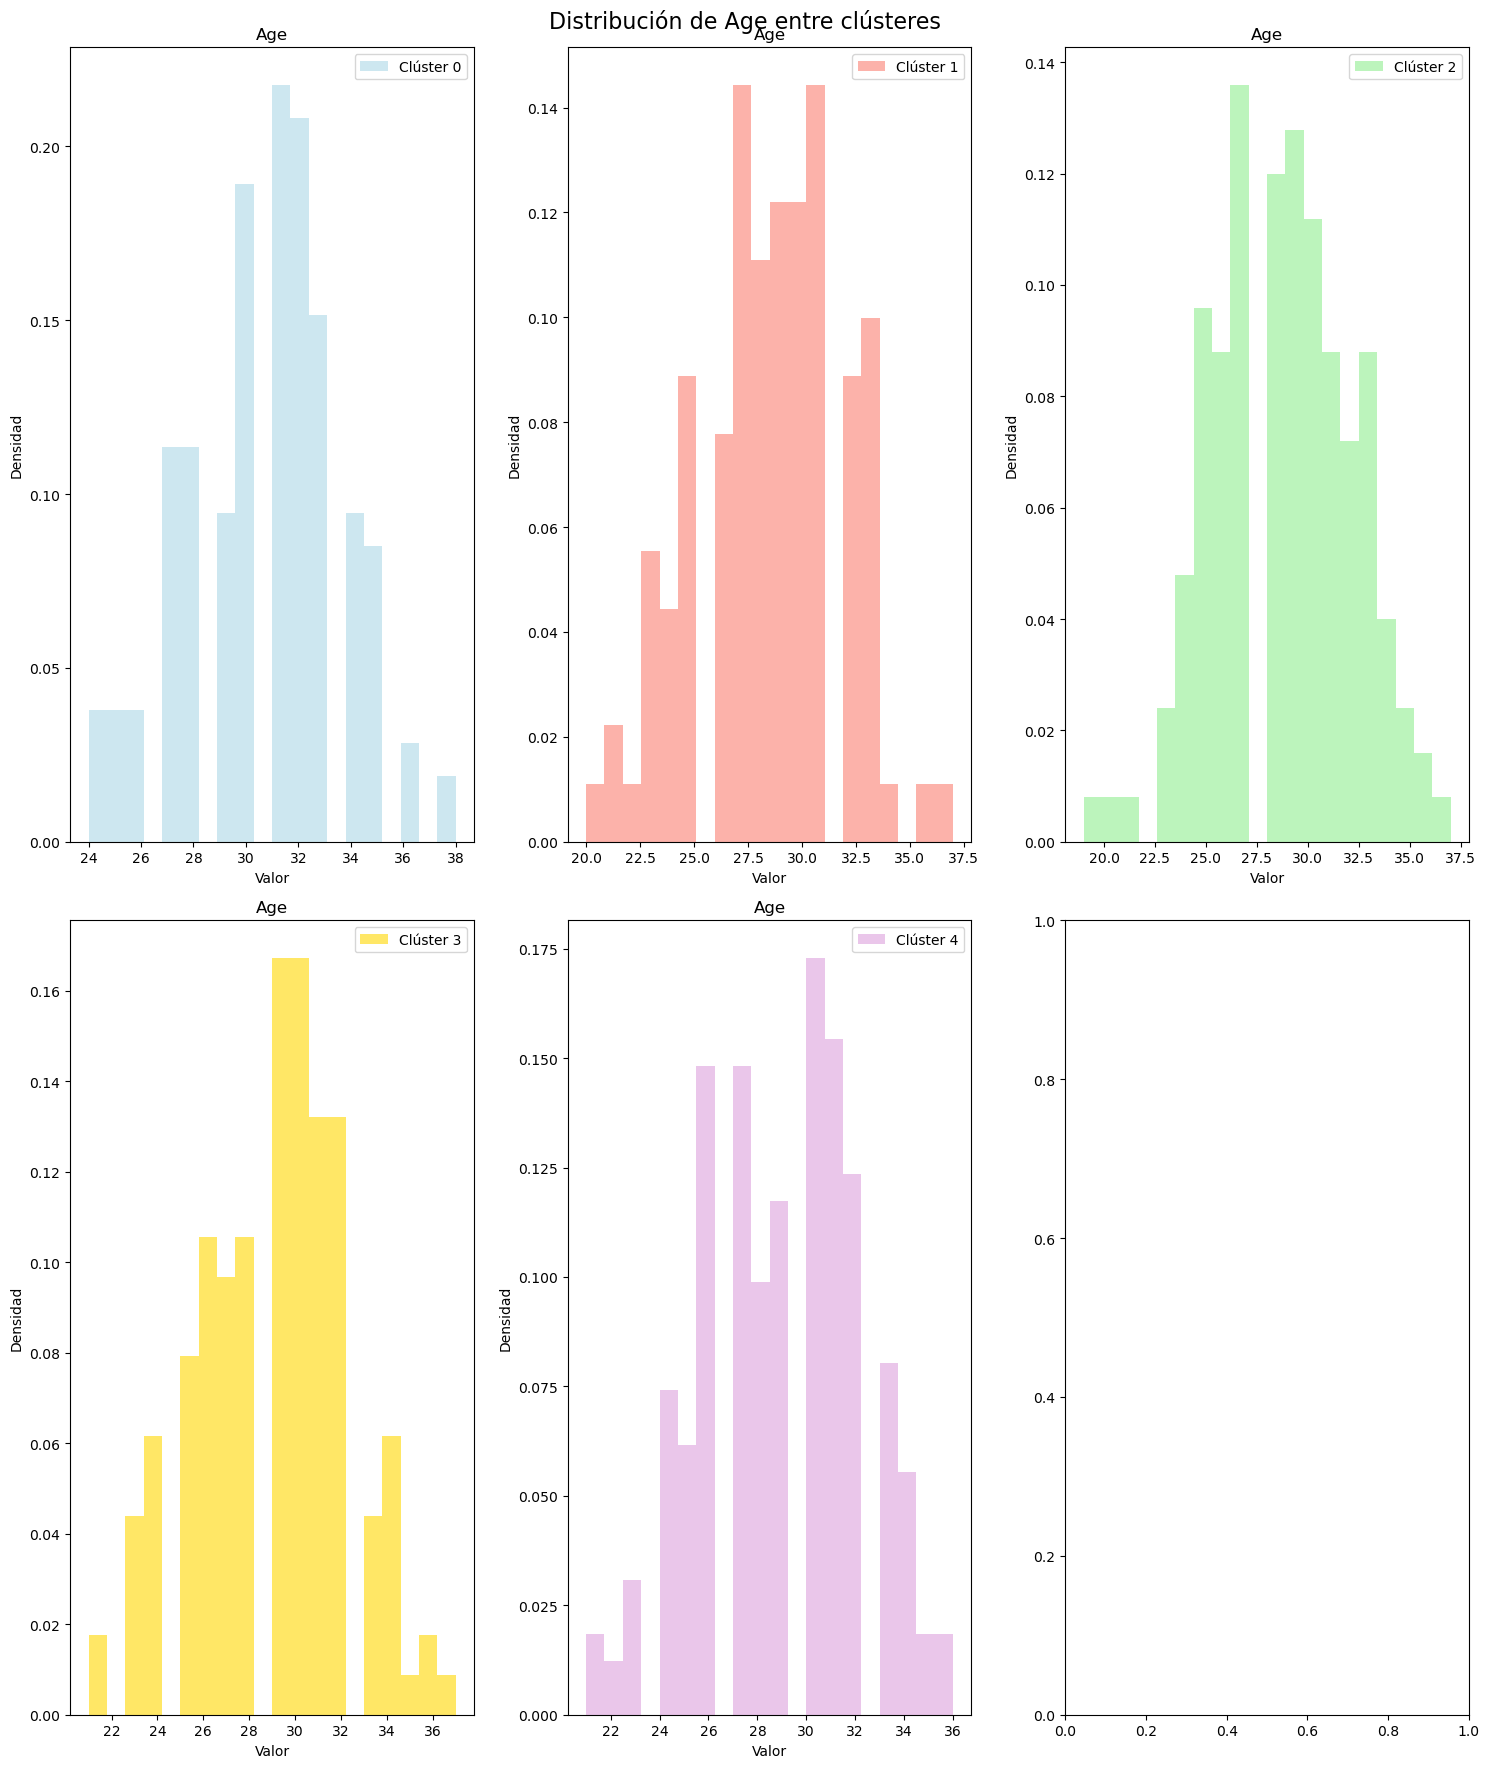

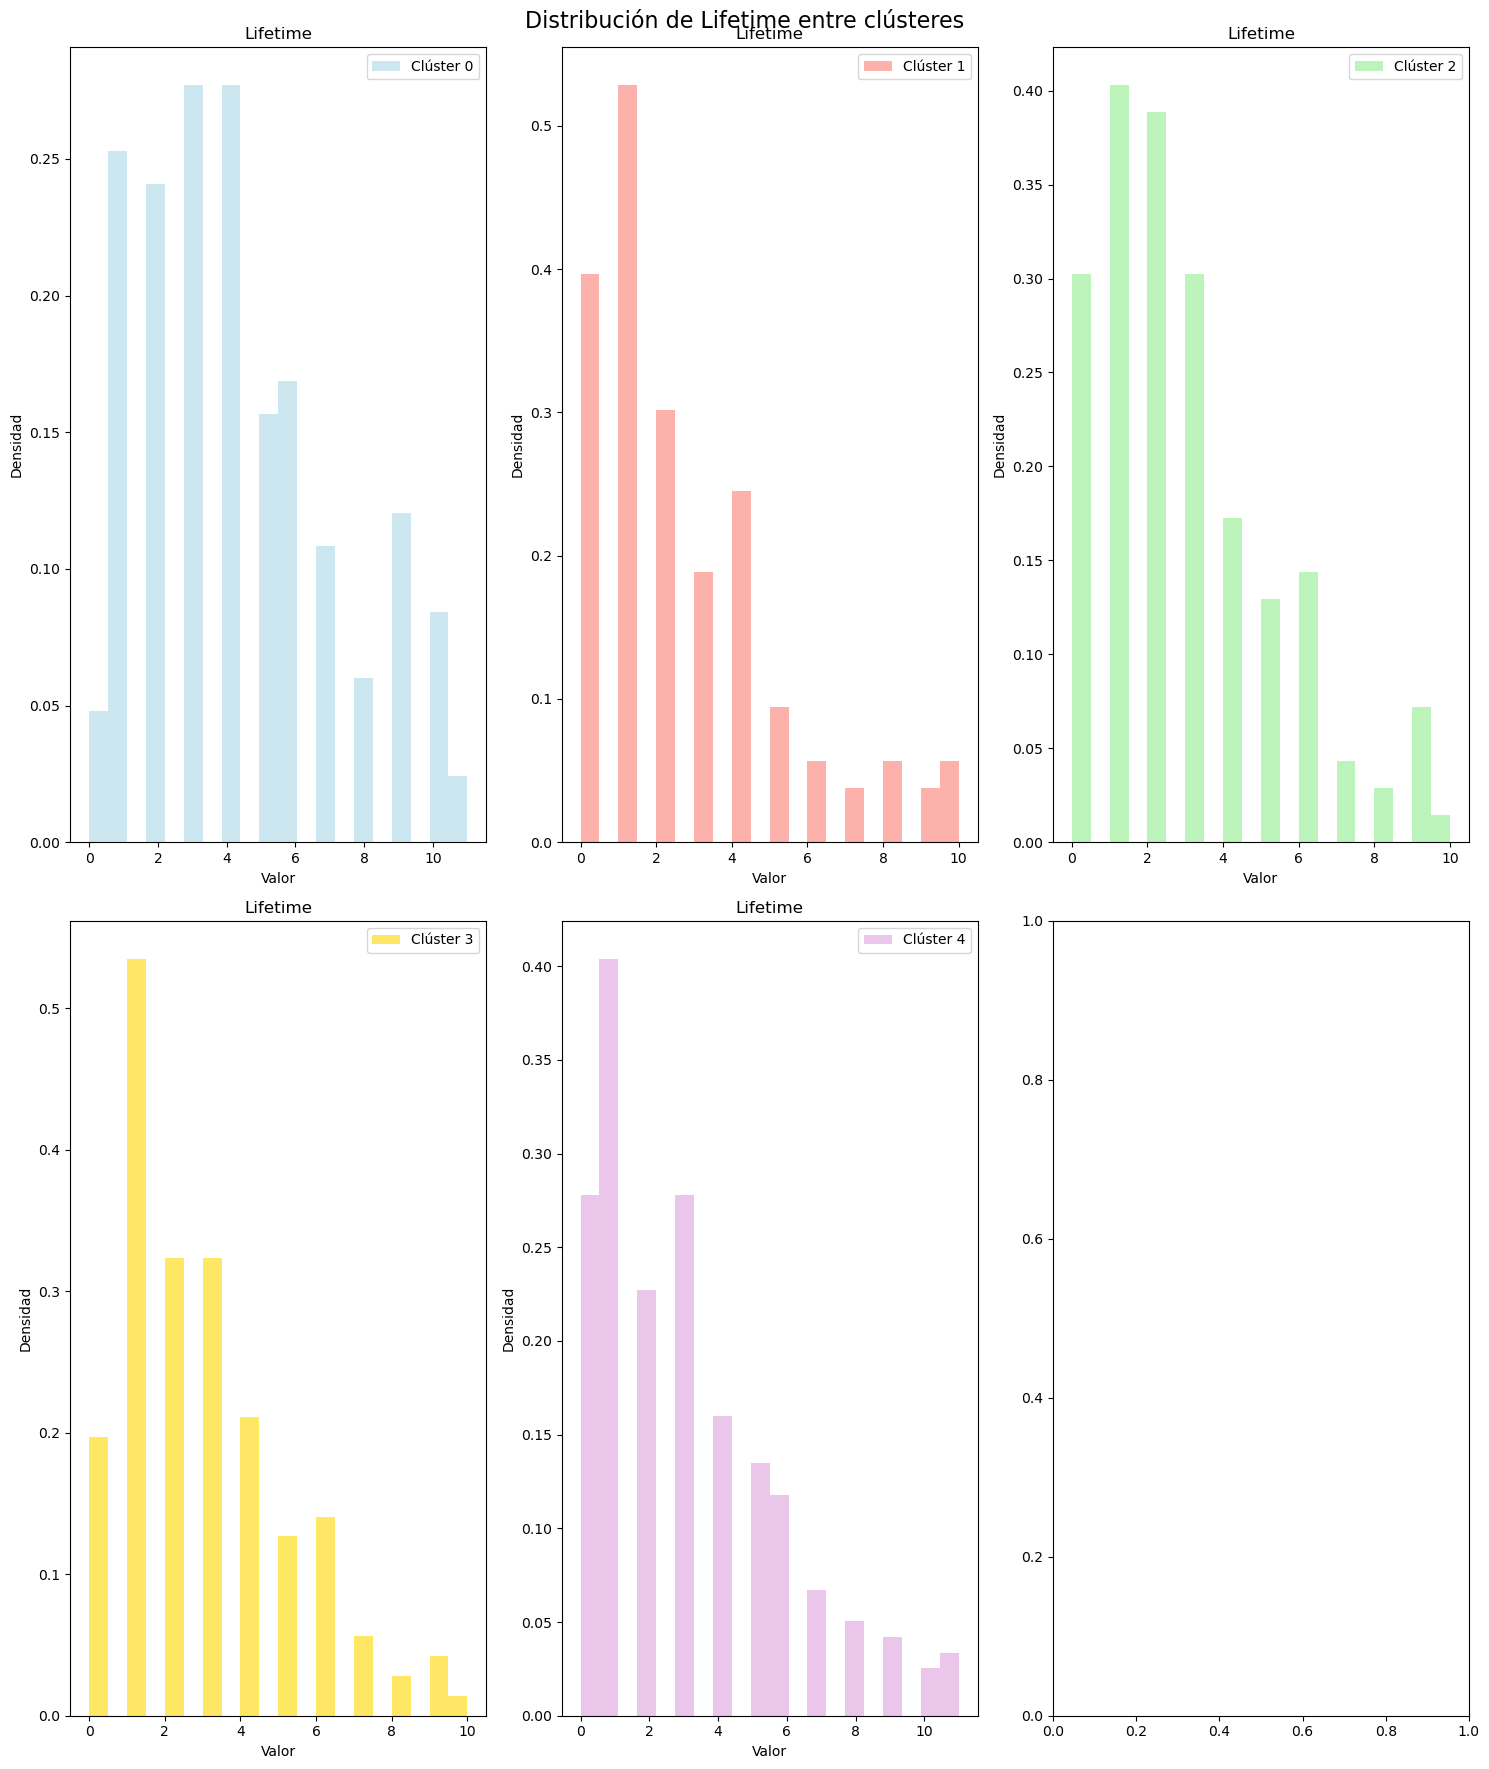

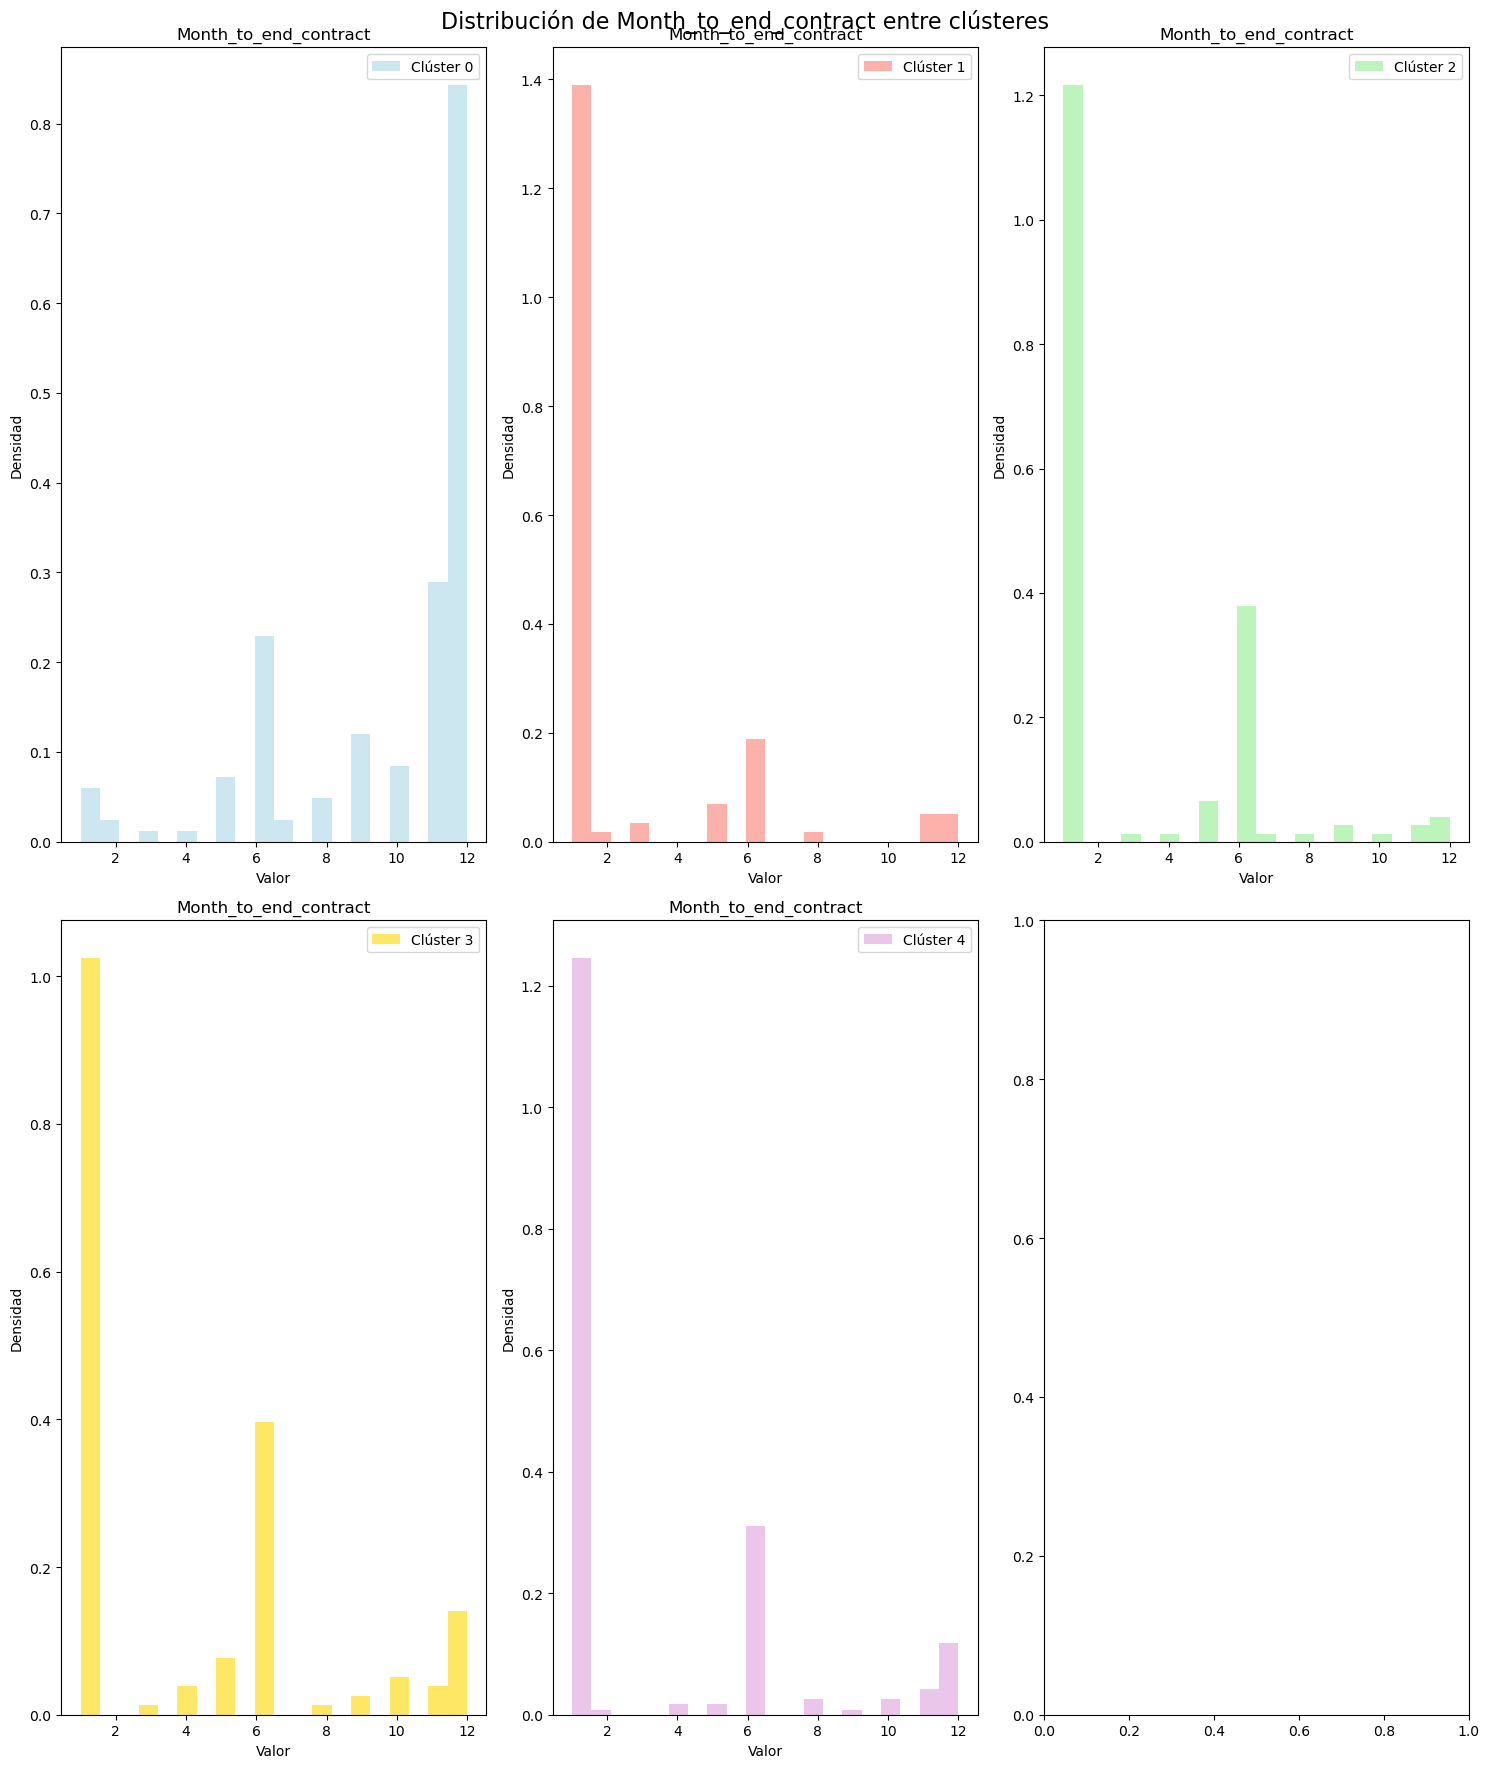

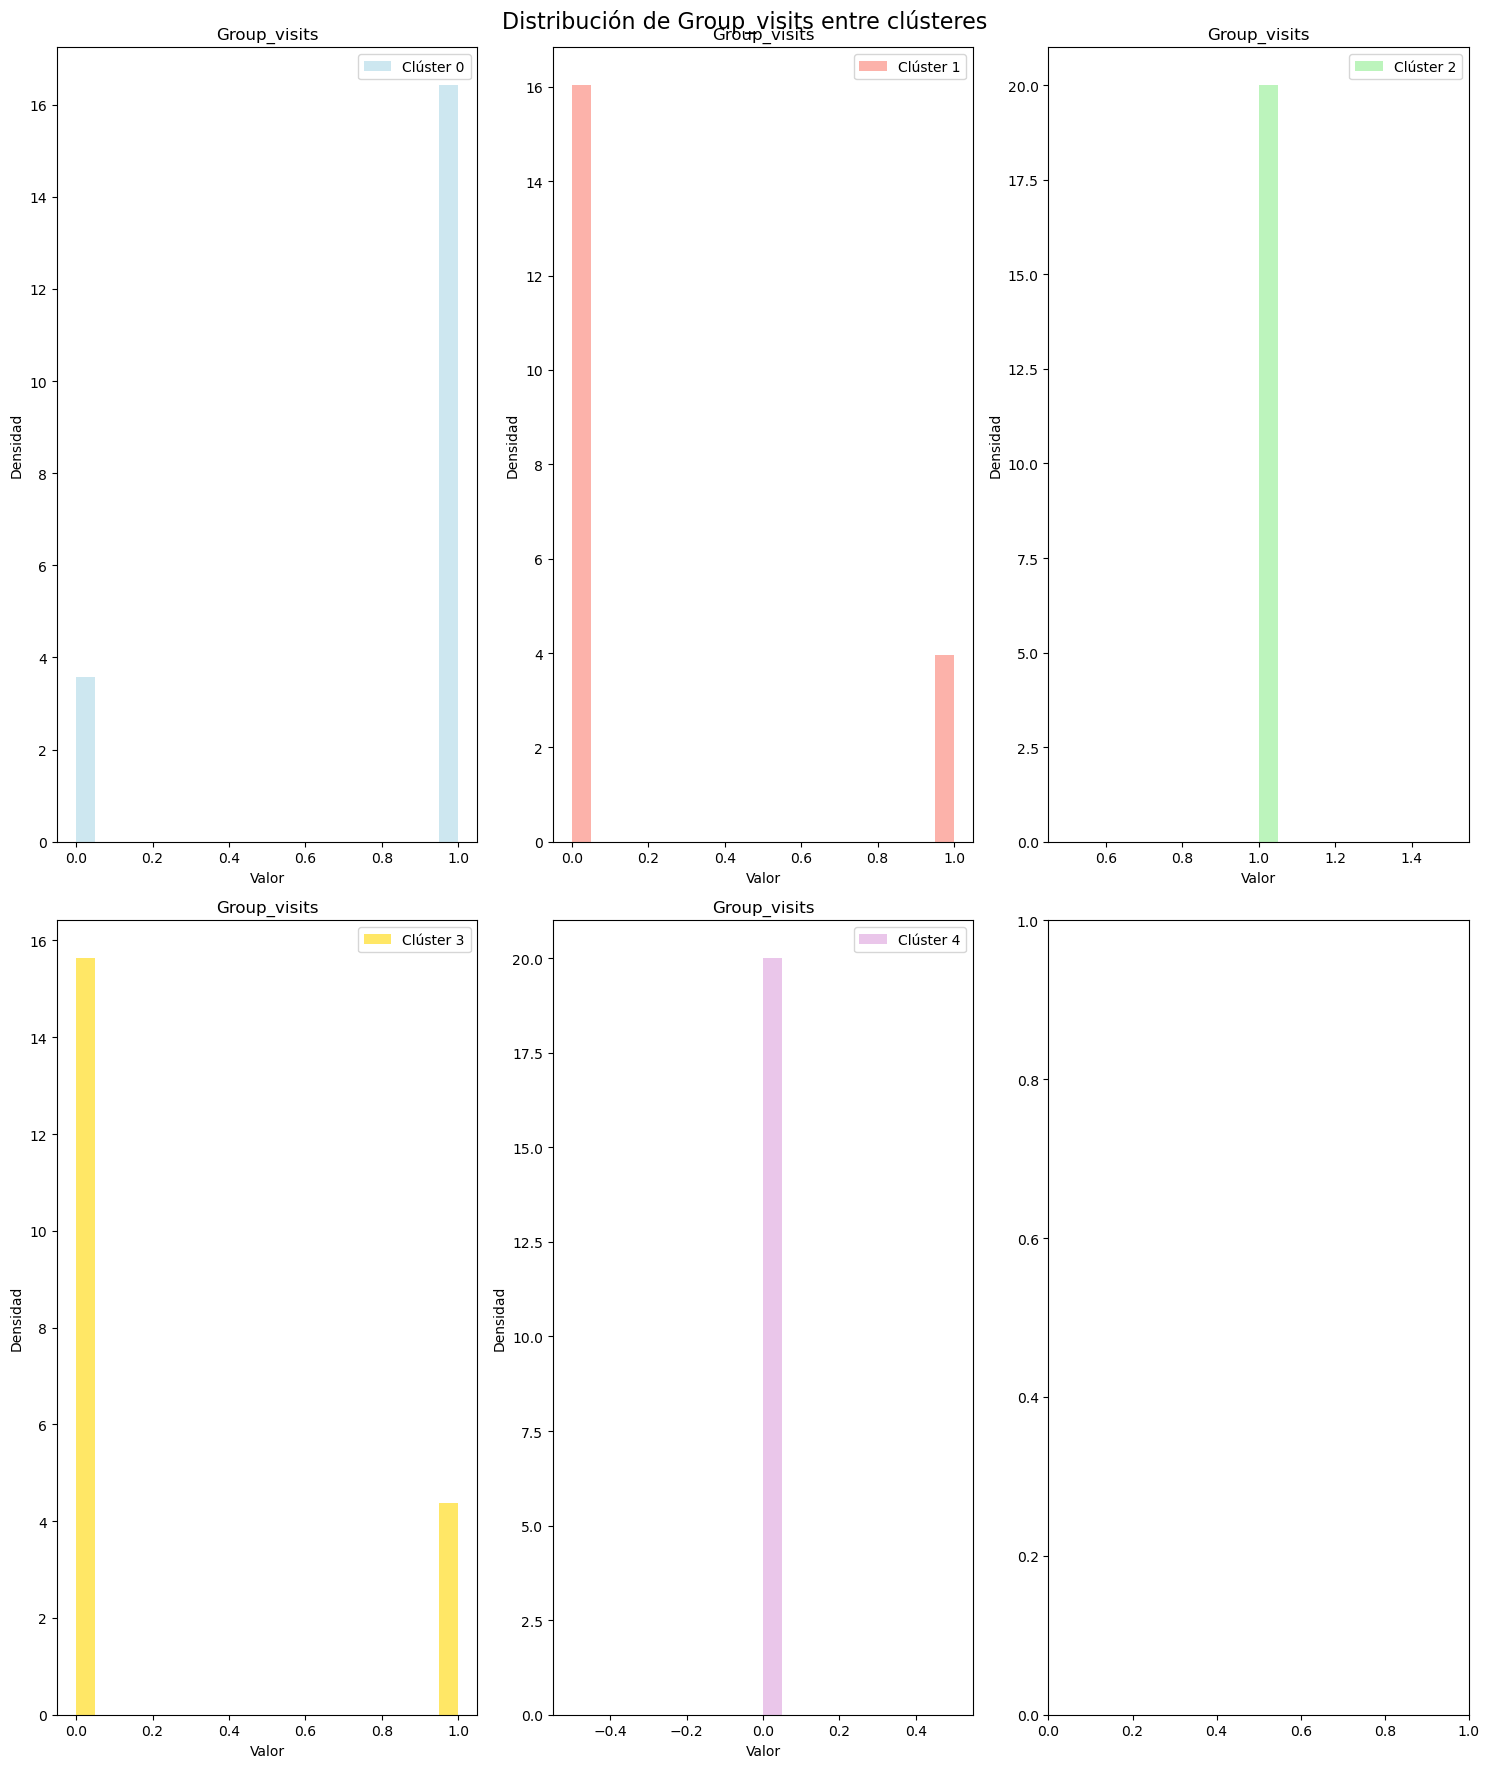

In [17]:
def feature_by_clusters(df, feature_name):
    '''
    Esta función genera gráficos de distribución de una característica 
    del escenario de estudio, pensando en traer los datos de los 5 clústeres.
    
    Parameters
    ----------
    feature_name : string
        Nombre de la característica de la que se imprimirá sus distribuciones
    df : pandas.Series
        Matriz de características, sin estandarizar, y sin valores de churn
    
    Returns
    -------
    Impresión de los gráficos de distribución de la característica por clústeres
    '''
    # Colores para cada clúster
    cluster_colors = ['lightblue', 'salmon', 'lightgreen', 'gold', 'plum']
    
    # Crear la figura
    plt.style.use('default')
    fig, axes = plt.subplots(2, 3, figsize=(15, 18))
    fig.suptitle(f"Distribución de {feature_name} entre clústeres", fontsize=16)
    
    # Aquí necesitas un bucle que recorra los 5 clústeres (0 a 4)
    for i in range(5):
        row = i // 3 
        col = i % 3
        # Para cada clúster, extraer los datos de la característica
        cluster_data = df[df['Cluster'] == i][feature_name]
        
        # Crear el histograma
        axes[row, col].hist(cluster_data, bins=20, alpha=0.6, 
                label=f'Clúster {i}', color=cluster_colors[i], density=True)
        axes[row, col].set_title(f'{feature_name}')
        axes[row, col].set_xlabel('Valor')
        axes[row, col].set_ylabel('Densidad')
        axes[row, col].legend()

    plt.tight_layout()
    plt.show()

variables = [
'gender','Near_Location', 'Partner', 'Promo_friends', 'Phone','Age', 
             'Lifetime','Month_to_end_contract','Group_visits'
]
for i in variables:
    feature_by_clusters(X_test_with_clusters, i)

Con base en los valores medios que se obtuvieron, se puede ver que cada clúster tiene características muy distintivas:

**Clúster 0 - "Promocionales VIP":**
- Promo_friends = 1.0 (todos vinieron por amigos)
- Near_Location = 0.995 (casi todos viven cerca)
- Partner = 0.894 (mayoría en empresas asociadas)

**Clúster 1 - "Comprometidos de largo plazo":**
- Month_to_end_contract = 6.04 (contratos más largos)
- Lifetime = 4.51 (mayor permanencia)
- Age = 30.92 (los más mayores)

**Clúster 2 - "Distantes geográficamente":**
- Near_Location = 0.0 (nadie vive cerca)
- Month_to_end_contract = 2.56 (contratos más cortos)

**Clúster 3 - "Nuevos y jóvenes":**
- Age = 26.92 (los más jóvenes)
- Lifetime = 1.71 (menor permanencia)
- Month_to_end_contract = 1.95 (contratos cortos)

**Clúster 4 - "Sin contacto telefónico":**
- Phone = 0.0 (nadie proporcionó teléfono)

## Tasa de cancelación para cada clúster

In [18]:
# Agrupación de Dataframe original con columna Churn, mediante clúster
X_test_with_clusters['Churn'] = y_test
cluster_cancellation_rate = X_test_with_clusters.groupby("Cluster")["Churn"].mean().reset_index()
cluster_cancellation_rate.columns = ['Cluster','Cancellation_rate']
print(cluster_cancellation_rate)

   Cluster  Cancellation_rate
0        0           0.006623
1        1           0.471698
2        2           0.258993
3        3           0.267606
4        4           0.314815


***¿Difieren en términos de tasa de cancelación?***

Sí, definitivamente hay diferencias significativas:

Clúster 3: 55.8% de cancelación (¡MUY ALTO!)

Clúster 2: 44.9% de cancelación (ALTO)

Clúster 4: 17.2% de cancelación (MODERADO)

Clúster 0: 13.9% de cancelación (BAJO)

Clúster 1: 1.5% de cancelación (MUY BAJO)

***¿Qué grupos son propensos a irse y cuáles son leales?***

GRUPOS PROPENSOS A IRSE:

Clúster 3 - "Nuevos y jóvenes" (55.8% cancelación)
- Edad promedio: 26.9 años (los más jóvenes)
- Lifetime: 1.7 meses (muy nuevos)
- Contratos cortos: 1.95 meses

Clúster 2 - "Distantes geográficamente" (44.9% cancelación)
- Nadie vive cerca del gimnasio
- Contratos más cortos: 2.56 meses
- Menor engagement general

GRUPOS LEALES:

Clúster 1 - "Comprometidos de largo plazo" (1.5% cancelación)
- Mayor permanencia: 4.51 meses
- Contratos más largos: 6.04 meses
- Edad madura: 30.9 años

Clúster 0 - "Promocionales VIP" (13.9% cancelación)
- Todos vinieron por recomendación de amigos
- Viven cerca del gimnasio
- Trabajan en empresas asociadas

# Paso 5. Conclusiones y recomendaciones básicas sobre el trabajo con clientes

## CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS
### GRUPOS OBJETIVO PRIORITARIOS
**ALTA PRIORIDAD - Clúster 3 "Nuevos y jóvenes" (55.8% cancelación)**

Perfil: Clientes de 26.9 años promedio, nuevos (1.7 meses), contratos cortos

**PRIORIDAD MEDIA - Clúster 2 "Distantes geográficamente" (44.9% cancelación)**

Perfil: Ninguno vive cerca del gimnasio, contratos cortos

Acciones específicas:
- Convenios con apps de transporte (Uber/taxi con descuento)
- Horarios extendidos para mayor flexibilidad
- Clases virtuales complementarias
- Programa de referidos con bonificaciones especiales

### MEDIDAS PARA REDUCIR LA ROTACIÓN

**A) ESTRATEGIAS PREVENTIVAS**

Para nuevos miembros (primeros 3 meses):

- Metas progresivas personalizadas
- Descuentos progresivos por permanencia

**B) ESTRATEGIAS DE RETENCIÓN ACTIVA**

Monitoreo de señales de alerta:

- Frecuencia de visitas < 1.5 veces/mes → Intervención inmediata
- Contratos de 1 mes → Oferta automática de extensión con beneficios
- Sin teléfono registrado → Campaña especial de contacto

### APROVECHAMIENTO DE GRUPOS LEALES

**Clúster 1 "Comprometidos de largo plazo" (1.5% cancelación)**

Estrategia: Convertirlos en embajadores de marca

Acciones:

- Programa VIP con beneficios exclusivos
- Comisiones por referir nuevos miembros
- Acceso prioritario a nuevas clases/equipos

**Clúster 0 "Promocionales VIP" (13.9% cancelación)**

Estrategia: Maximizar el poder del marketing boca a boca

Acciones:

- Ampliar programa de referidos
- Eventos especiales para empresas asociadas
- Descuentos familiares/grupales

### MÉTRICAS DE SEGUIMIENTO RECOMENDADAS
KPIs mensuales por clúster:

- Tasa de cancelación por grupo
- Frecuencia promedio de visitas
- Tiempo promedio de permanencia
- ROI de programas de retención específicos